In [1]:
%load_ext autoreload

In [2]:
%autoreload 2
%aimport sog1_helpers
from sparrow import Protein
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

import metapredict as meta

In [3]:
def percent_helicity(seq):
    P = Protein(seq) 
    output = P.predictor.dssp_helicity()
    return sum(output) / len(output)

def end_to_end_dist(seq):
    P = Protein(seq)
    return P.predictor.end_to_end_distance(use_scaled=True)

In [4]:
all_shuffle_vars = pd.read_csv("../data/all_shuffle_vars.csv")
all_shuffle_vars

,Unnamed: 0,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,...,Activity_S3_1_wt,Activity_S3_2_wt,lib2_avg_wt,vars,AAs,tile,shuffle_size,coordinates,pos_start,pos_end
0,0,321,360,33_shuffle_size2_ss2_pos0_1,shuffle_size2_ss2_pos0_1,341,MELDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,763.760346,695.590132,729.675239,...,735.085200,895.351926,815.218563,"[321, 322]","['E', 'M']",33,2,0_1,321,323
1,1,321,360,33_shuffle_size2_ss2_pos1_1,shuffle_size2_ss2_pos1_1,341,EMDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1473.675797,1687.523804,1580.599801,...,735.085200,895.351926,815.218563,"[323, 324]","['L', 'D']",33,2,1_1,323,325
2,2,321,360,33_shuffle_size2_ss2_pos2_1,shuffle_size2_ss2_pos2_1,341,EMLDKDEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1706.977440,1719.464603,1713.221022,...,735.085200,895.351926,815.218563,"[325, 326]","['D', 'K']",33,2,2_1,325,327
3,3,321,360,33_shuffle_size2_ss2_pos4_1,shuffle_size2_ss2_pos4_1,341,EMLDDKEEEQKDRDNENQGEEDPTWFDSGSQFILNSQQLV,325.349781,627.000002,476.174892,...,735.085200,895.351926,815.218563,"[329, 330]","['Q', 'E']",33,2,4_1,329,331
4,4,321,360,33_shuffle_size2_ss2_pos5_1,shuffle_size2_ss2_pos5_1,341,EMLDDKEEQEDKRDNENQGEEDPTWFDSGSQFILNSQQLV,677.584266,878.104555,777.844411,...,735.085200,895.351926,815.218563,"[331, 332]","['K', 'D']",33,2,5_1,331,333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568,3568,410,449,42_shuffle_size10_ss2_pos15_6,shuffle_size10_ss2_pos15_6,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSLWTGADFGTK,908.291934,601.458747,754.875341,...,1962.781522,1933.058378,1947.919950,"[440, 441, 442, 443, 444, 445, 446, 447, 449]","['F', 'L', 'A', 'W', 'G', 'T', 'G', 'K', 'D']",42,10,15_6,440,450
3569,3569,410,449,42_shuffle_size10_ss2_pos15_7,shuffle_size10_ss2_pos15_7,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTTKGDALWFG,3620.400685,3866.897601,3743.649143,...,1962.781522,1933.058378,1947.919950,"[440, 441, 442, 443, 444, 445, 446, 447, 448, ...","['F', 'L', 'A', 'W', 'G', 'T', 'G', 'K', 'T', ...",42,10,15_7,440,450
3570,3570,410,449,42_shuffle_size10_ss2_pos15_8,shuffle_size10_ss2_pos15_8,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTLDFGKGATW,1014.433117,629.787497,822.110307,...,1962.781522,1933.058378,1947.919950,"[440, 442, 443, 445, 447, 449]","['F', 'A', 'W', 'T', 'K', 'D']",42,10,15_8,440,450
3571,3571,410,449,42_shuffle_size10_ss2_pos15_9,shuffle_size10_ss2_pos15_9,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTWFTGGADLK,2375.766170,1866.065374,2120.915772,...,1962.781522,1933.058378,1947.919950,"[440, 441, 442, 443, 445, 446, 447, 448, 449]","['F', 'L', 'A', 'W', 'T', 'G', 'K', 'T', 'D']",42,10,15_9,440,450


In [5]:
helicities = []
end_to_end_distances = []
for seq in all_shuffle_vars["tile_var"]:
    helicities.append(percent_helicity(seq))
    end_to_end_distances.append(end_to_end_dist(seq))

Error importing GPy.
 If trying to run parrot-optimize, make sure to use `pip install idptools-parrot[optimize]`


In [6]:
all_shuffle_vars["helicity"] = helicities
all_shuffle_vars["end_to_end"] = end_to_end_distances
all_shuffle_vars

,Unnamed: 0,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,...,lib2_avg_wt,vars,AAs,tile,shuffle_size,coordinates,pos_start,pos_end,helicity,end_to_end
0,0,321,360,33_shuffle_size2_ss2_pos0_1,shuffle_size2_ss2_pos0_1,341,MELDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,763.760346,695.590132,729.675239,...,815.218563,"[321, 322]","['E', 'M']",33,2,0_1,321,323,0.0,44.168199
1,1,321,360,33_shuffle_size2_ss2_pos1_1,shuffle_size2_ss2_pos1_1,341,EMDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1473.675797,1687.523804,1580.599801,...,815.218563,"[323, 324]","['L', 'D']",33,2,1_1,323,325,0.0,44.742841
2,2,321,360,33_shuffle_size2_ss2_pos2_1,shuffle_size2_ss2_pos2_1,341,EMLDKDEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1706.977440,1719.464603,1713.221022,...,815.218563,"[325, 326]","['D', 'K']",33,2,2_1,325,327,0.0,44.660848
3,3,321,360,33_shuffle_size2_ss2_pos4_1,shuffle_size2_ss2_pos4_1,341,EMLDDKEEEQKDRDNENQGEEDPTWFDSGSQFILNSQQLV,325.349781,627.000002,476.174892,...,815.218563,"[329, 330]","['Q', 'E']",33,2,4_1,329,331,0.0,44.339531
4,4,321,360,33_shuffle_size2_ss2_pos5_1,shuffle_size2_ss2_pos5_1,341,EMLDDKEEQEDKRDNENQGEEDPTWFDSGSQFILNSQQLV,677.584266,878.104555,777.844411,...,815.218563,"[331, 332]","['K', 'D']",33,2,5_1,331,333,0.0,43.952220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568,3568,410,449,42_shuffle_size10_ss2_pos15_6,shuffle_size10_ss2_pos15_6,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSLWTGADFGTK,908.291934,601.458747,754.875341,...,1947.919950,"[440, 441, 442, 443, 444, 445, 446, 447, 449]","['F', 'L', 'A', 'W', 'G', 'T', 'G', 'K', 'D']",42,10,15_6,440,450,0.0,44.446552
3569,3569,410,449,42_shuffle_size10_ss2_pos15_7,shuffle_size10_ss2_pos15_7,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTTKGDALWFG,3620.400685,3866.897601,3743.649143,...,1947.919950,"[440, 441, 442, 443, 444, 445, 446, 447, 448, ...","['F', 'L', 'A', 'W', 'G', 'T', 'G', 'K', 'T', ...",42,10,15_7,440,450,0.0,42.868909
3570,3570,410,449,42_shuffle_size10_ss2_pos15_8,shuffle_size10_ss2_pos15_8,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTLDFGKGATW,1014.433117,629.787497,822.110307,...,1947.919950,"[440, 442, 443, 445, 447, 449]","['F', 'A', 'W', 'T', 'K', 'D']",42,10,15_8,440,450,0.0,45.132755
3571,3571,410,449,42_shuffle_size10_ss2_pos15_9,shuffle_size10_ss2_pos15_9,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTWFTGGADLK,2375.766170,1866.065374,2120.915772,...,1947.919950,"[440, 441, 442, 443, 445, 446, 447, 448, 449]","['F', 'L', 'A', 'W', 'T', 'G', 'K', 'T', 'D']",42,10,15_9,440,450,0.0,44.190105


In [7]:
# Which tiles have nonzero helices?
all_shuffle_vars[all_shuffle_vars["helicity"] != 0]["tile"].value_counts()

tile
34    707
35    702
41    563
42    104
33     88
Name: count, dtype: int64

In [11]:
palette = sns.color_palette('colorblind')

In [12]:
def within_helix_1(tile):
    tile_34 = all_shuffle_vars[all_shuffle_vars["tile"] == tile]
    tile_34_helix = tile_34[tile_34["pos_start"] >= 356]
    tile_34_helix = tile_34_helix[tile_34_helix["pos_end"] <= 371]
    sns.scatterplot(data = tile_34_helix[tile_34_helix["shuffle_size"] > 2], x = "helicity", y = "Activity_S3_1_var", alpha = 0.5, edgecolor = 'none', color = palette[0], s = 15) 
    sns.despine()
    plt.title("Tile " + str(tile))
    
    plt.axvline(percent_helicity(tile_34["tile_wt"].iloc[0]), color = "red", zorder = 0, alpha = 0.25)
    plt.axhline(tile_34["Activity_S3_1_wt"].iloc[0], color = "red", zorder = 0, alpha = 0.25)

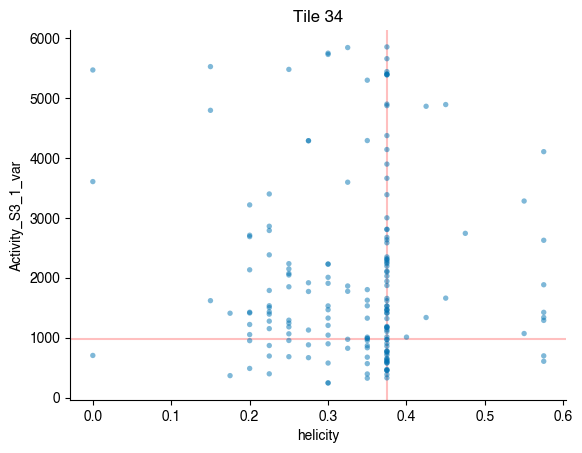

In [13]:
within_helix_1(34)

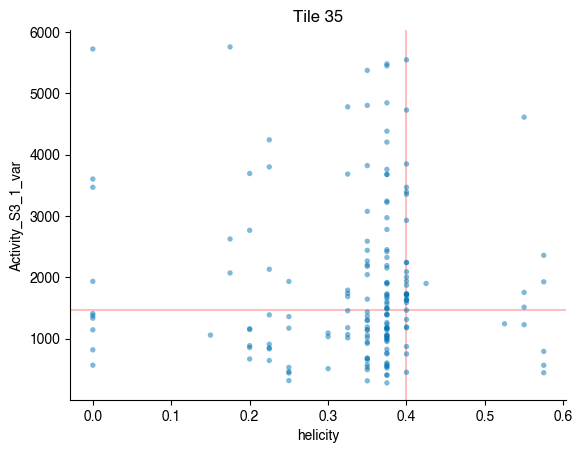

In [14]:
within_helix_1(35)

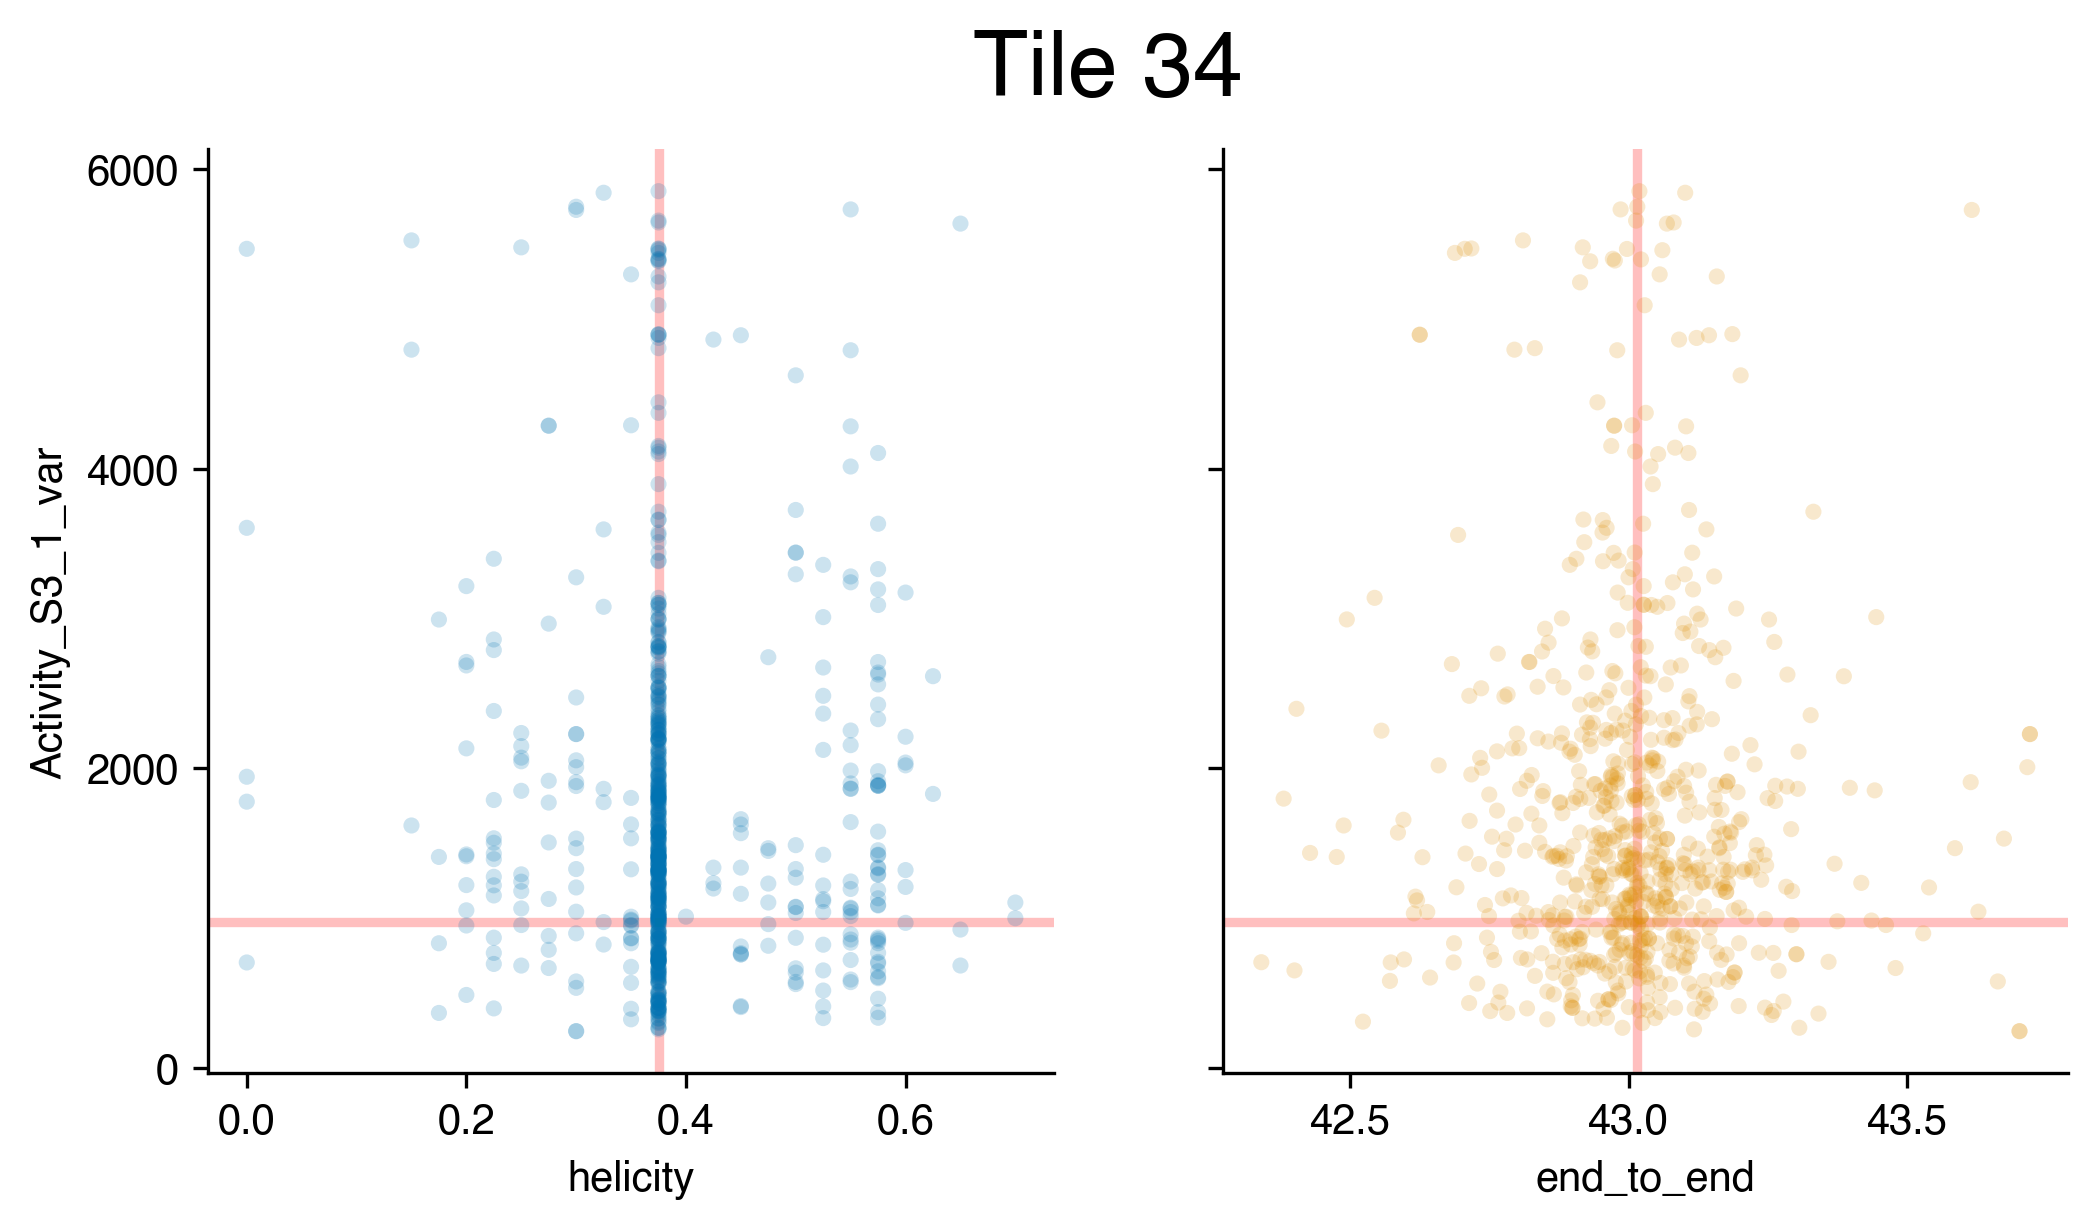

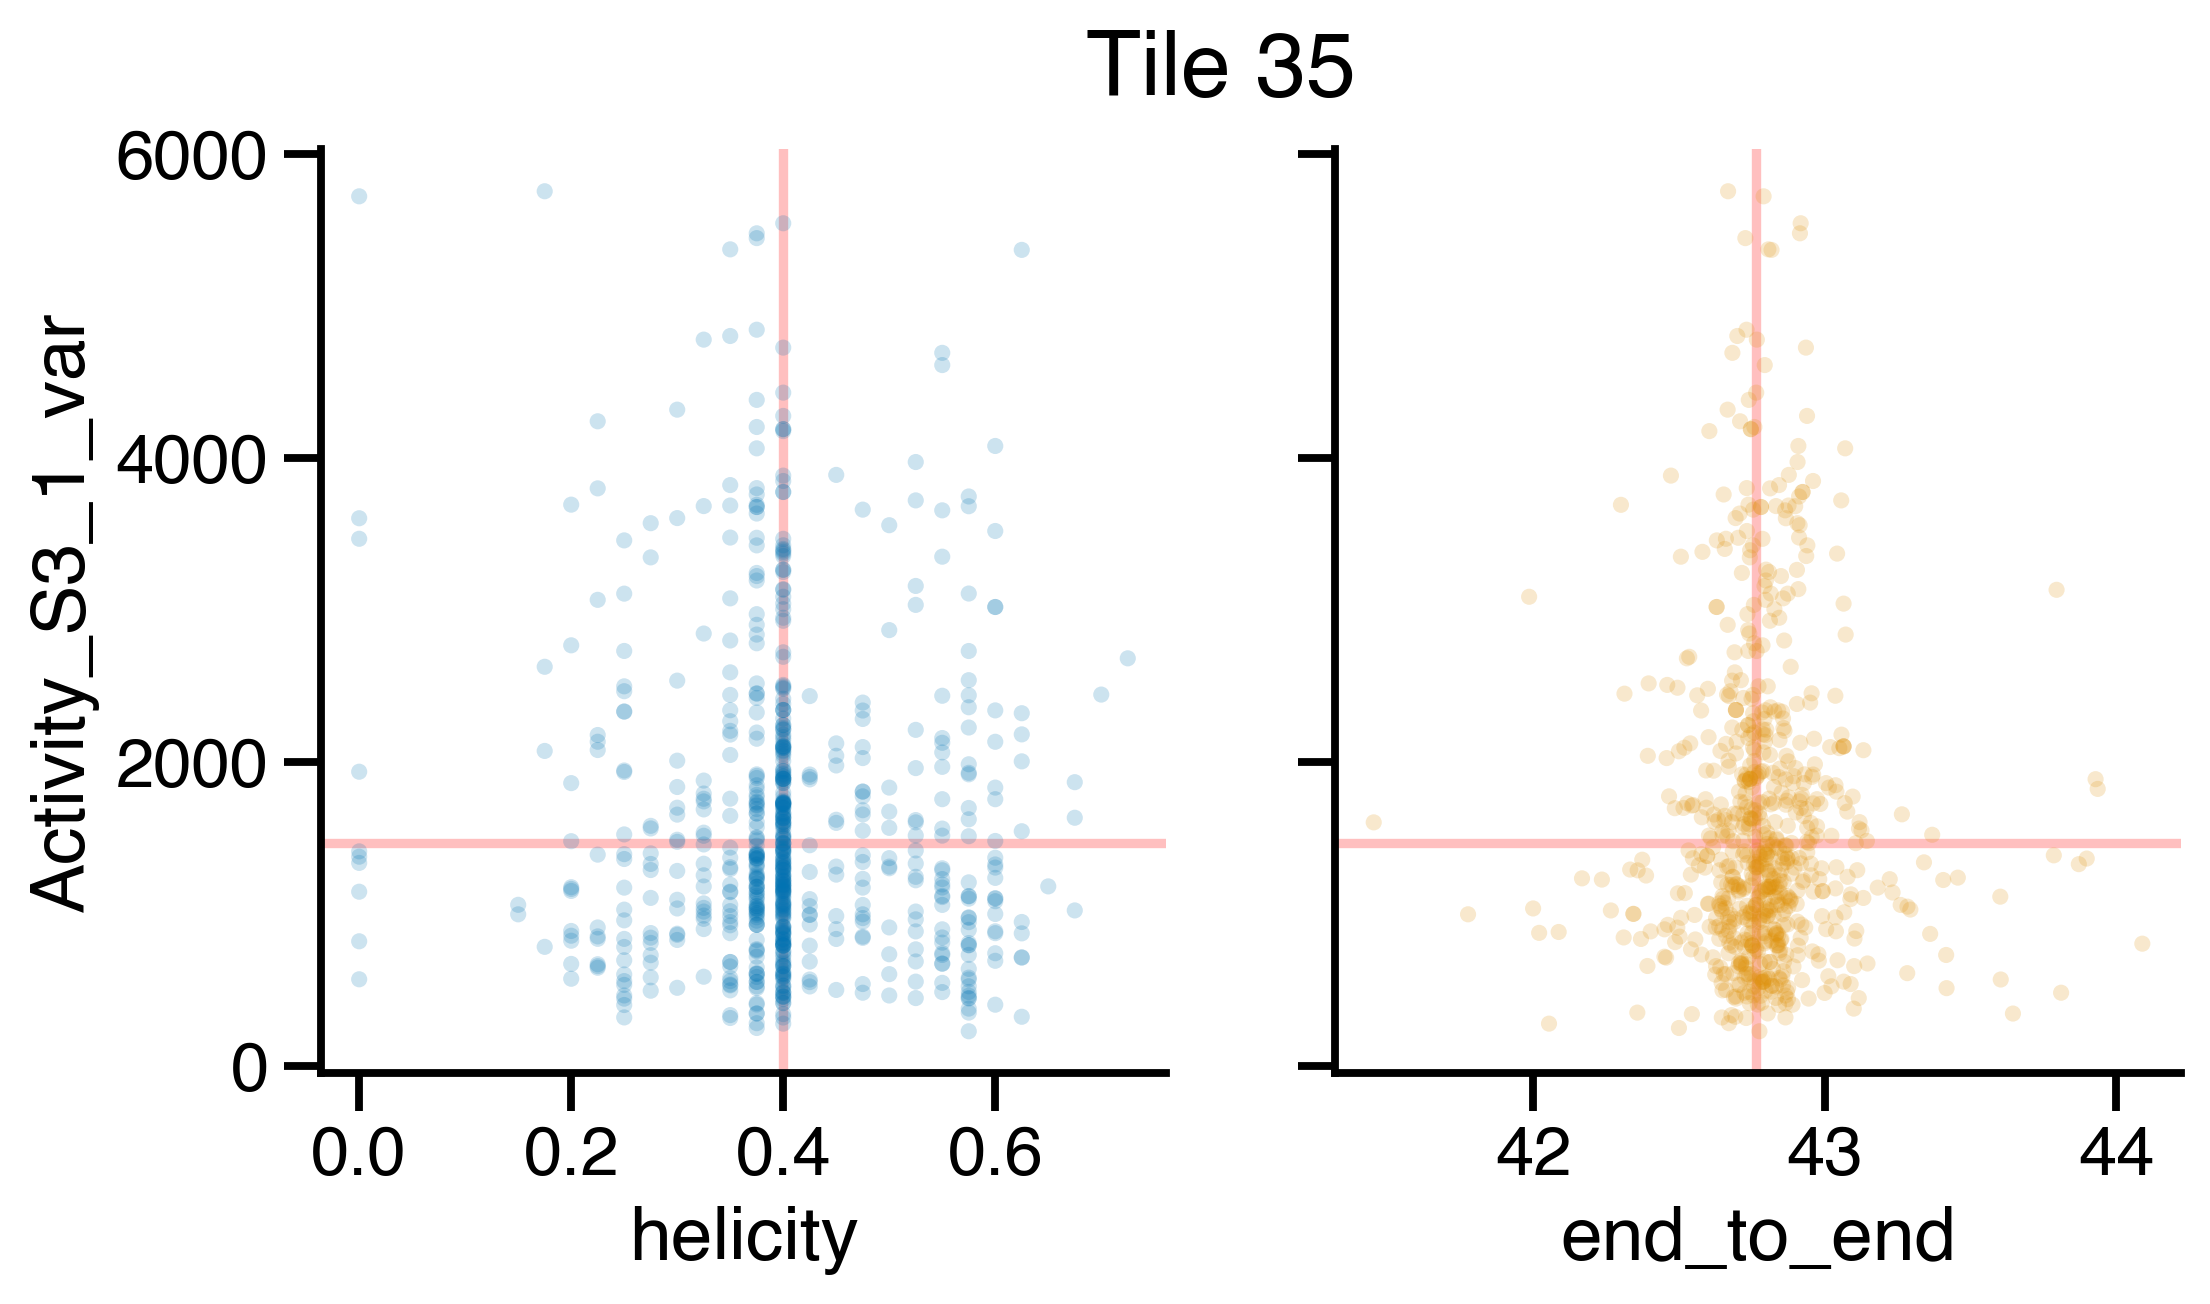

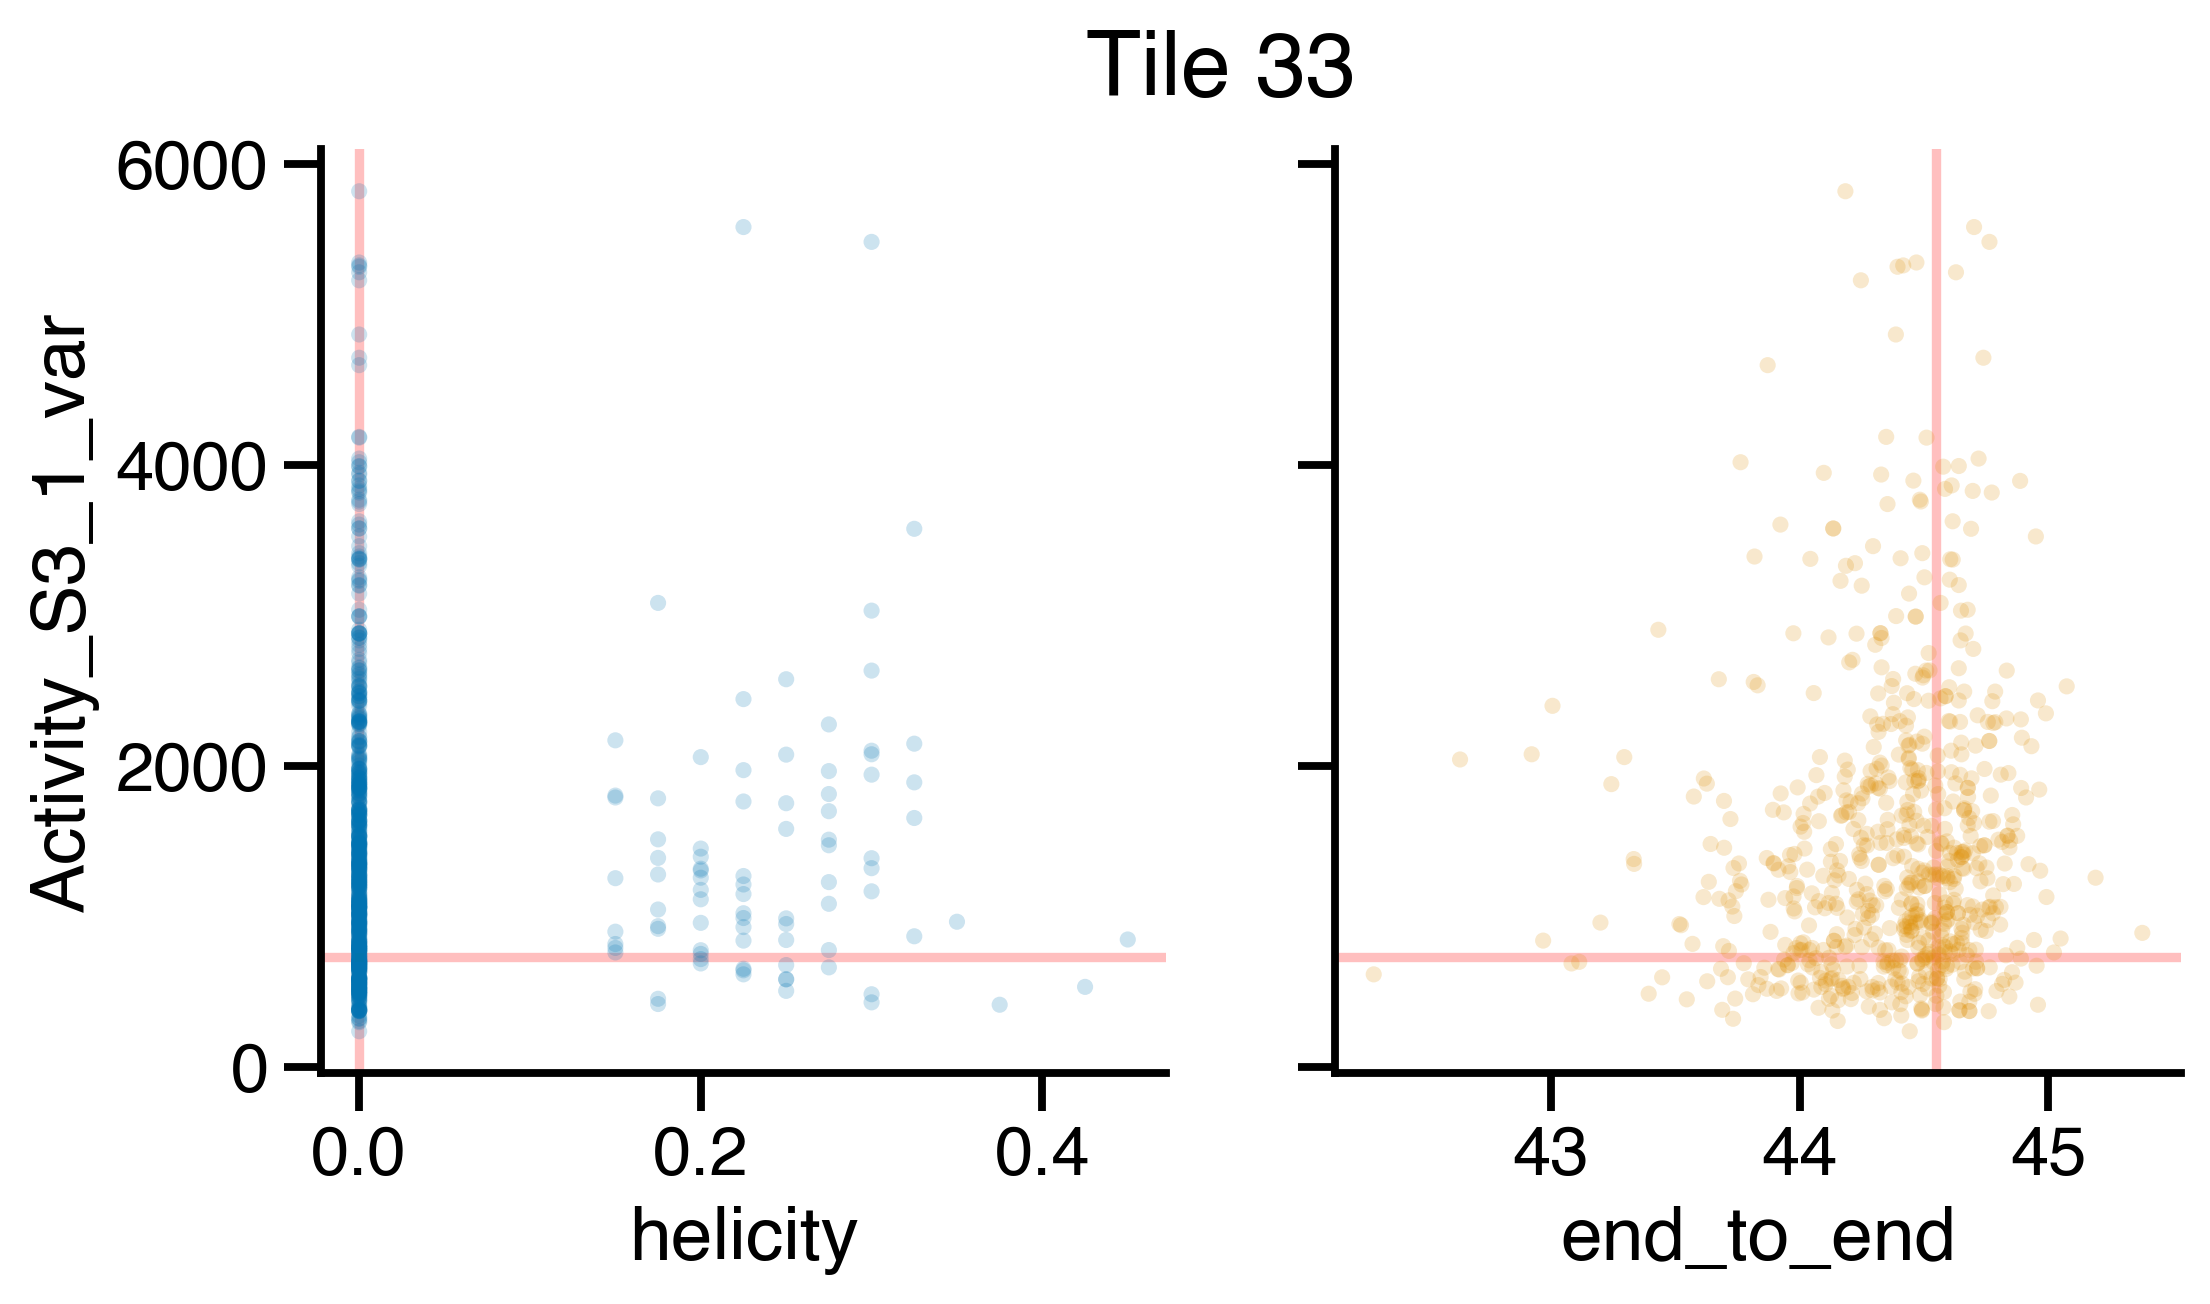

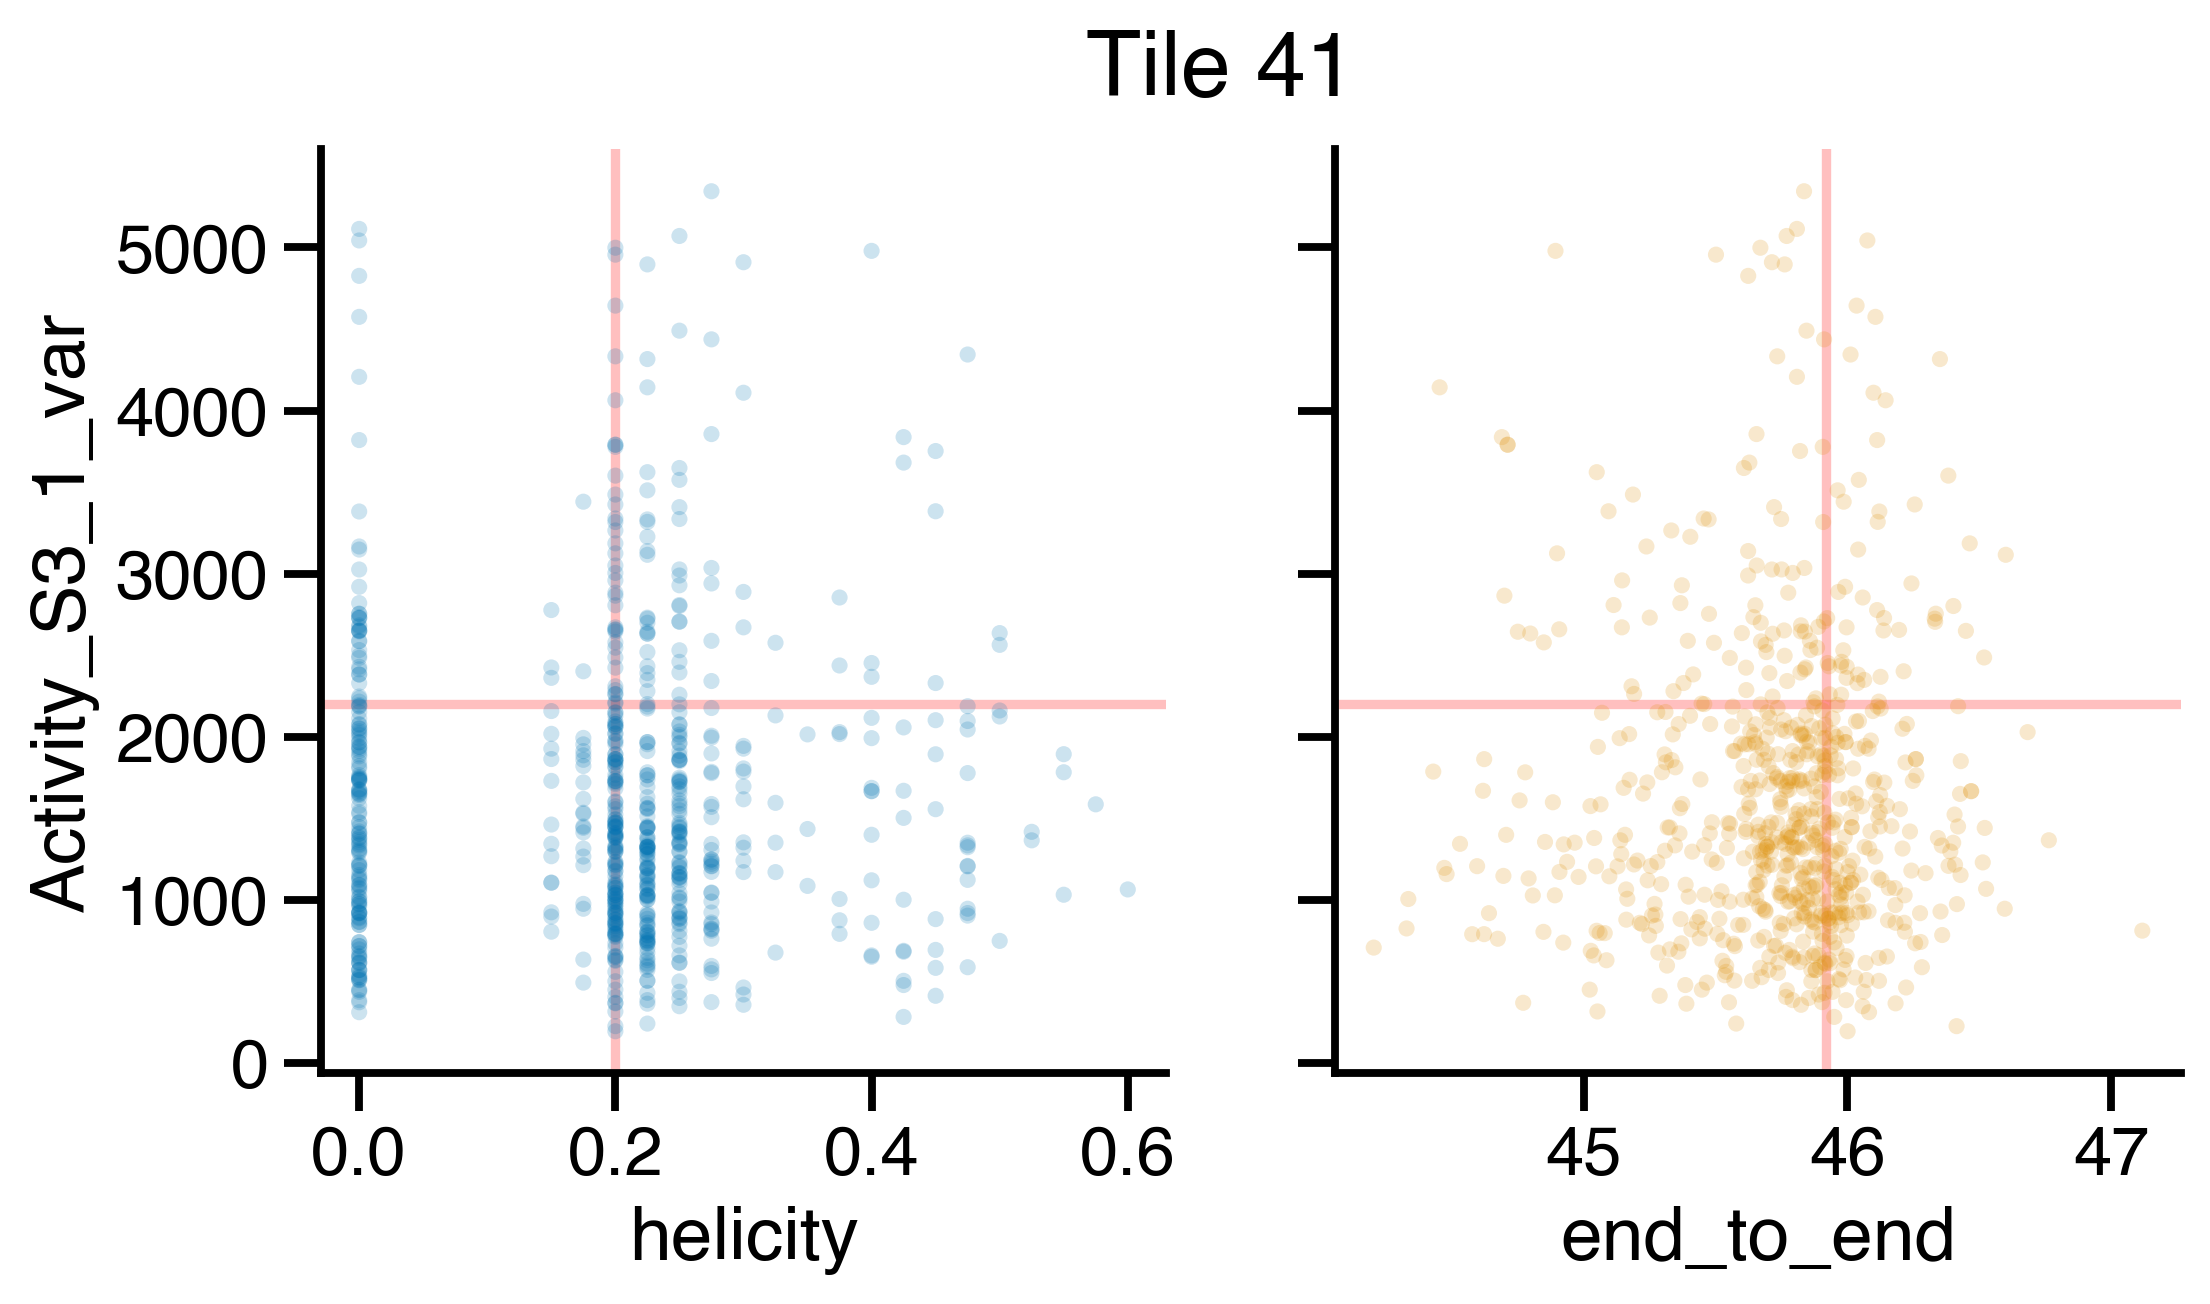

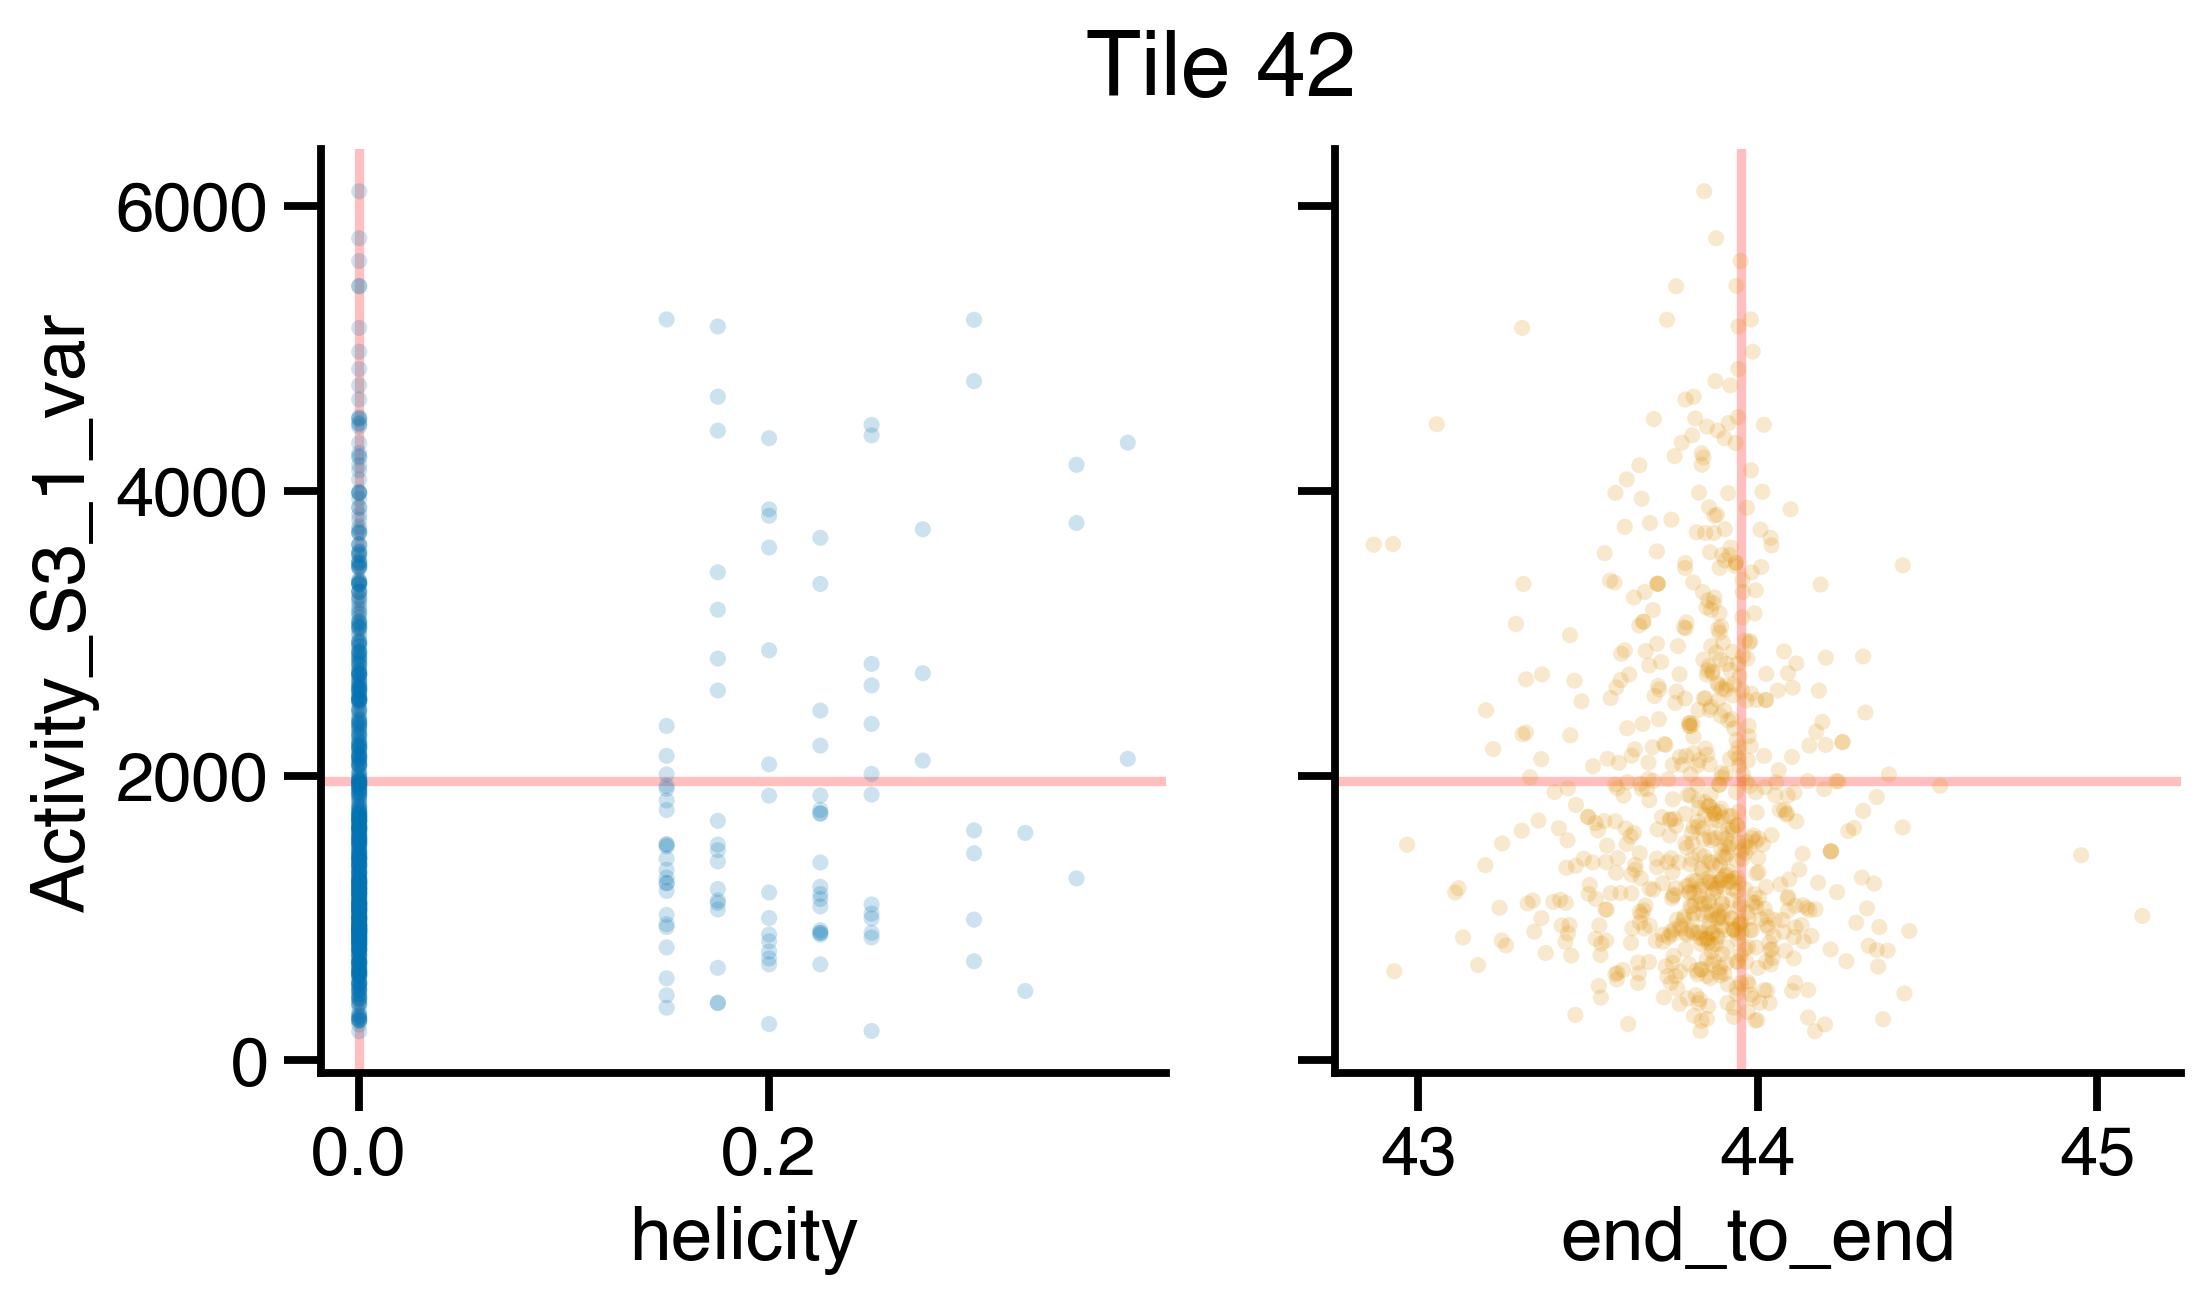

In [15]:
# Starting with tile 34
for tile in all_shuffle_vars[all_shuffle_vars["helicity"] != 0]["tile"].unique():
    fig, axs = plt.subplots(1, 2, sharey = True, figsize = (8, 4), dpi = 300)
    
    one_tile = all_shuffle_vars[all_shuffle_vars["tile"] == tile]

    palette = sns.color_palette('colorblind')
    
    sns.set_context('talk')
    sns.scatterplot(data = one_tile[one_tile["shuffle_size"] > 2], x = "helicity", y = "Activity_S3_1_var", alpha = 0.2, edgecolor = 'none', ax = axs[0], color = palette[0], s = 15)
    axs[0].axvline(percent_helicity(one_tile["tile_wt"].iloc[0]), color = "red", zorder = 0, alpha = 0.25)
    axs[0].axhline(one_tile["Activity_S3_1_wt"].iloc[0], color = "red", zorder = 0, alpha = 0.25)

    sns.scatterplot(data = one_tile[one_tile["shuffle_size"] > 2], x = "end_to_end", y = "Activity_S3_1_var", alpha = 0.2, edgecolor = 'none', ax = axs[1], color = palette[1], s = 15)
    axs[1].axvline(end_to_end_dist(one_tile["tile_wt"].iloc[0]), color = "red", zorder = 0, alpha = 0.25)
    axs[1].axhline(one_tile["Activity_S3_1_wt"].iloc[0], color = "red", zorder = 0, alpha = 0.25)

    sns.despine()
    plt.suptitle("Tile " + str(tile))
    plt.show()

# What is helicity of WT sequence?

In [16]:
wt_seq = "".join(pd.read_csv("../data/Sog1_AA_features.csv")["aa"])
wt_seq

'MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKAYSTGTRKRRKIHDDDFGDVRWHKTGRTKPVVLDGVQRGCKKIMVLYGGKAVKTNWVMHQYHLGIEEDEKEGDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATPEPRNAVRICSDSHIASDYVTPSDYVSAHEVSLAETSEVMCMEDEVQSIQPNHERPSSGPELEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLLGSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD'

In [17]:
wt_helix_preds = Protein(wt_seq).predictor.dssp_helicity()
wt_helix_preds

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [18]:
starts = []
ends = []

prev_num = 0
for i in range(len(wt_helix_preds)):
    if wt_helix_preds[i] == 1 and prev_num == 0:
        starts.append(i)
    if wt_helix_preds[i] == 0 and prev_num == 1:
        ends.append(i)
    prev_num = wt_helix_preds[i]

In [19]:
pred_helices = list(zip(starts, ends))
pred_helices

[(9, 17), (68, 78), (118, 131), (355, 370), (398, 412)]

In [20]:
# WT tiles
BasicArTh = sog1_helpers.return_activities("BasicArTh", pos_regex = r'\.(\d+)')
BasicArTh.head(3)

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end
0,1,40,BasicArTh.1,Q6NQK2,21,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,4745,578.263724,889.304271,12,-311.040547,1467.567995
1,11,50,BasicArTh.2,Q6NQK2,31,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4968,465.385382,365.182128,7,100.203254,830.567509
2,21,60,BasicArTh.3,Q6NQK2,41,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,6208,680.357455,370.567756,11,309.789699,1050.925211


In [21]:
BasicArTh["helicity"] = BasicArTh["tile"].apply(lambda t: percent_helicity(t))
BasicArTh

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,helicity
0,1,40,BasicArTh.1,Q6NQK2,21,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,4745,578.263724,889.304271,12,-311.040547,1467.567995,0.225
1,11,50,BasicArTh.2,Q6NQK2,31,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4968,465.385382,365.182128,7,100.203254,830.567509,0.000
2,21,60,BasicArTh.3,Q6NQK2,41,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,6208,680.357455,370.567756,11,309.789699,1050.925211,0.000
3,31,70,BasicArTh.4,Q6NQK2,51,WKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPE,6737,1076.542492,1233.131826,8,-156.589334,2309.674317,0.000
4,41,80,BasicArTh.5,Q6NQK2,61,KCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSG,3553,753.360897,406.043485,13,347.317413,1159.404382,0.250
5,51,90,BasicArTh.6,Q6NQK2,71,VVDDWPGLPRGVKFDPSDPEIIWHLLAKSGLSGLSSHPFI,6654,1333.684743,539.101400,17,794.583343,1872.786144,0.250
6,61,100,BasicArTh.7,Q6NQK2,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQD,3019,972.904562,473.415780,11,499.488782,1446.320342,0.250
7,71,110,BasicArTh.8,Q6NQK2,91,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,3388,1704.401088,2314.845287,15,-610.444198,4019.246375,0.000
8,81,120,BasicArTh.9,Q6NQK2,101,LSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTV,4676,992.490299,1209.571573,18,-217.081274,2202.061872,0.000
9,91,130,BasicArTh.10,Q6NQK2,111,DEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,411,348.974668,137.172549,8,211.802119,486.147217,0.250


Q: Is helicity important for activity of ADs?

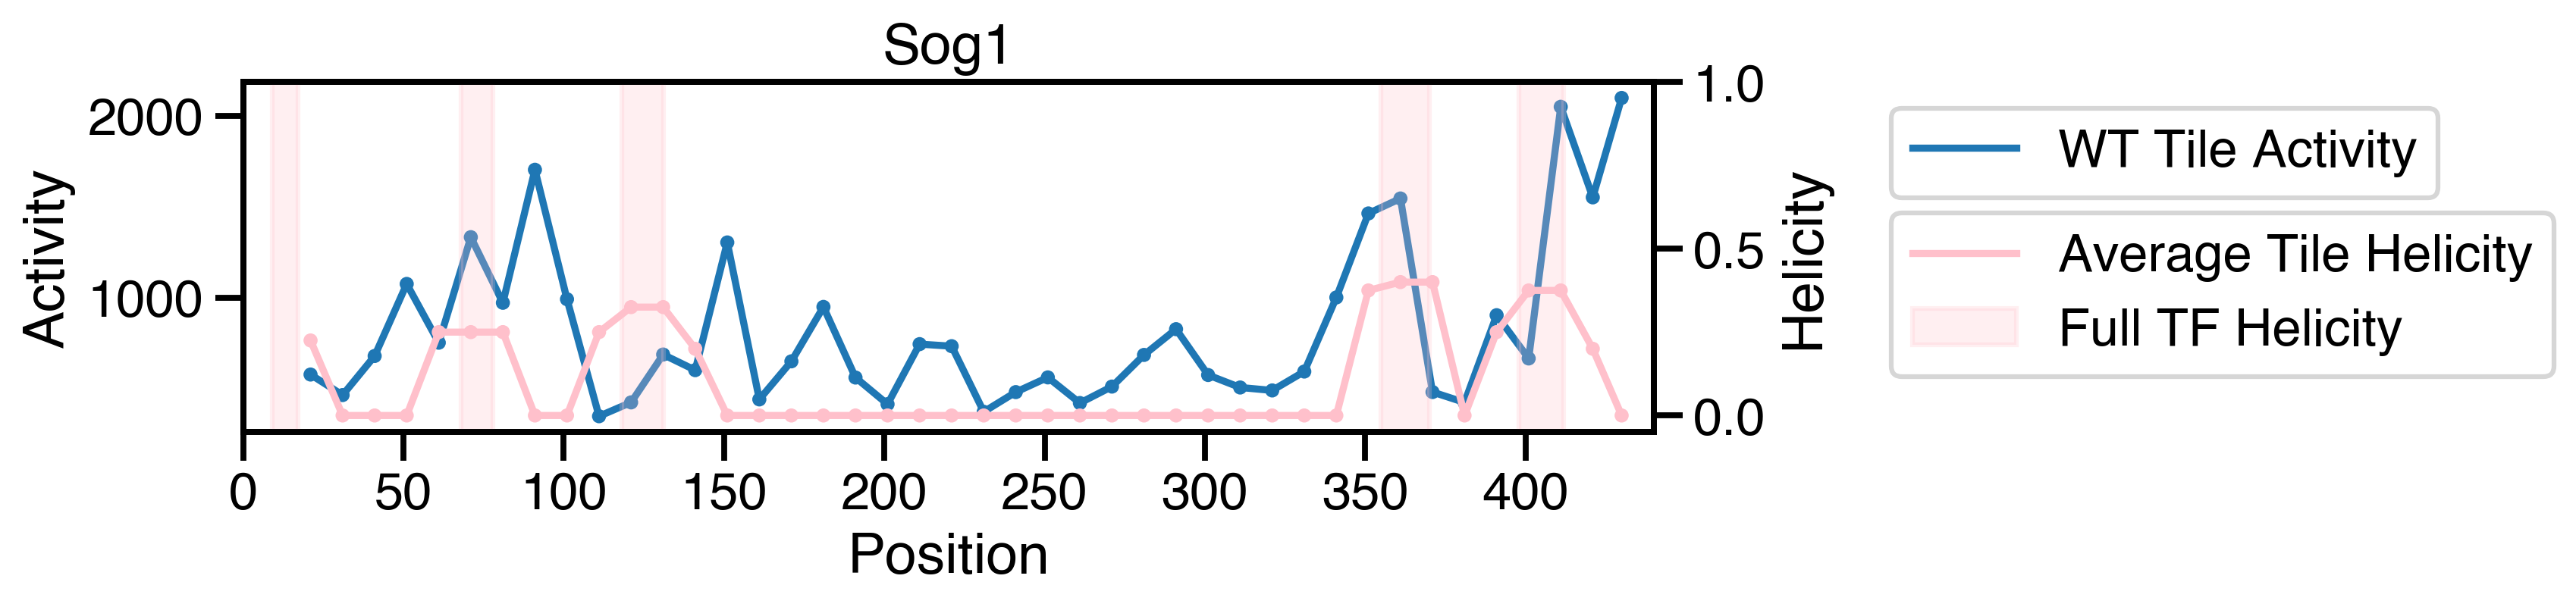

In [22]:
fig, ax = plt.subplots(figsize = (8, 2), dpi = 300)
sns.lineplot(data = BasicArTh, x = "mid", y = "Activity_S3_1", label = "WT Tile Activity", ax = ax, zorder = 10)
sns.scatterplot(data = BasicArTh, x = "mid", y = "Activity_S3_1", ax = ax, s = 20, edgecolor = 'none')


    
ax.set_title("Sog1")
ax.set_ylabel("Activity")
ax.set_xlabel("Position")

secax = ax.twinx()
sns.lineplot(data = BasicArTh, x = "mid", y = "helicity", color = 'pink', ax = secax, label = "Average Tile Helicity")
sns.scatterplot(data = BasicArTh, x = "mid", y = "helicity", color = 'pink', ax = secax, s = 20, edgecolor = 'none')
secax.set_ylabel("Helicity")
ax.set_xlim(0, 440)

label = True
for s, e in pred_helices:
    if label:
        secax.axvspan(s, e, alpha = 0.25, color = 'pink', label = "Full TF Helicity", zorder = 0)
        label = False
    else:
        secax.axvspan(s, e, alpha = 0.25, color = 'pink', zorder = 0)
secax.set_ylim(-0.05, 1)

ax.legend(bbox_to_anchor = (1.15,1))
secax.legend(bbox_to_anchor = (1.15,0.7))

#sns.despine()

In [23]:
sog1_aa_features = pd.read_csv("../data/Sog1_AA_features.csv")
sog1_aa_features["PS"] = sog1_aa_features["PS_lib2"] == "confirmed"
sog1_aa_features = sog1_aa_features[["pos", "PS"]]
sog1_aa_features

,pos,PS
0,1,False
1,2,False
2,3,False
3,4,False
4,5,False
...,...,...
444,445,False
445,446,False
446,447,False
447,448,False


In [24]:
ps_locs = sog1_aa_features[sog1_aa_features["PS"]]
ps_locs

,pos,PS
95,96,True
236,237,True
243,244,True
248,249,True
349,350,True
355,356,True
371,372,True
422,423,True
429,430,True
435,436,True


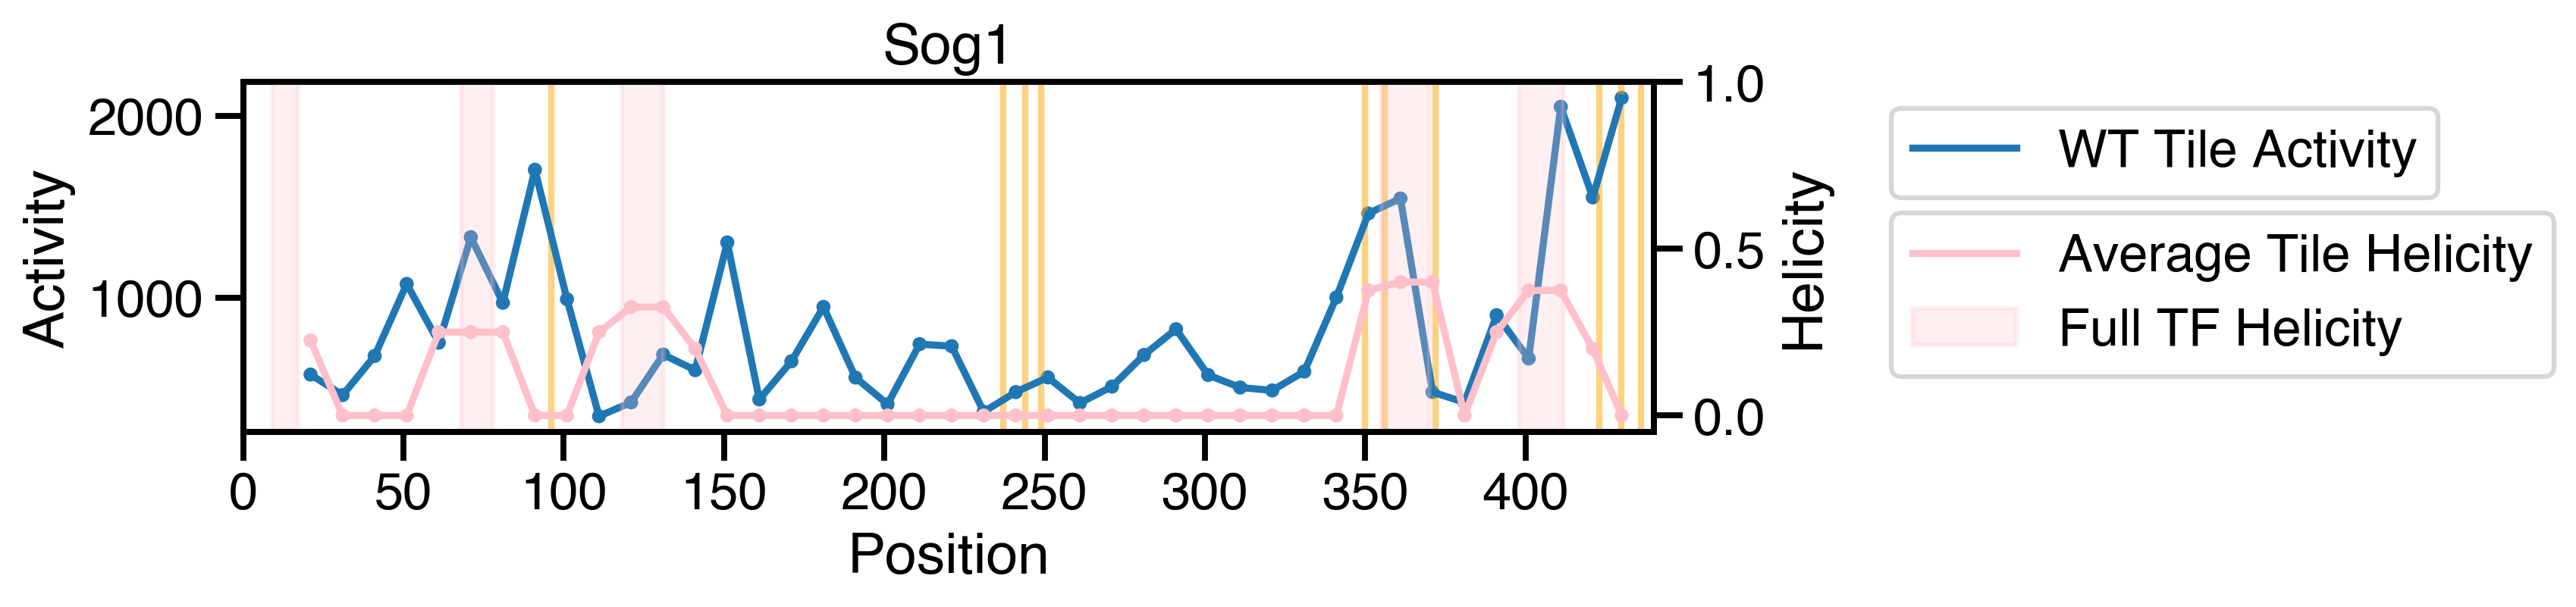

In [25]:
fig, ax = plt.subplots(figsize = (8, 2), dpi = 300)
sns.lineplot(data = BasicArTh, x = "mid", y = "Activity_S3_1", label = "WT Tile Activity", ax = ax, zorder = 10)
sns.scatterplot(data = BasicArTh, x = "mid", y = "Activity_S3_1", ax = ax, s = 20, edgecolor = 'none')


    
ax.set_title("Sog1")
ax.set_ylabel("Activity")
ax.set_xlabel("Position")
ax.set_xlim(0, 440)

for pos in ps_locs["pos"]:
    ax.axvline(pos, color = "orange", zorder = 5, alpha = 0.5, lw = 2)

secax = ax.twinx()
sns.lineplot(data = BasicArTh, x = "mid", y = "helicity", color = 'pink', ax = secax, label = "Average Tile Helicity")
sns.scatterplot(data = BasicArTh, x = "mid", y = "helicity", color = 'pink', ax = secax, s = 20, edgecolor = 'none')
secax.set_ylabel("Helicity")

label = True
for s, e in pred_helices:
    if label:
        secax.axvspan(s, e, alpha = 0.25, color = 'pink', label = "Full TF Helicity", zorder = 0)
        label = False
    else:
        secax.axvspan(s, e, alpha = 0.25, color = 'pink', zorder = 0)
secax.set_ylim(-0.05, 1)

ax.legend(bbox_to_anchor = (1.15,1))
secax.legend(bbox_to_anchor = (1.15,0.7))

#sns.despine()

In [26]:
BasicArTh[BasicArTh["Description"].str.contains("35")]

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,helicity
34,341,380,BasicArTh.35,Q6NQK2,361,EDPTWFDSGSQFILNSQQLVEALSLCDDLLGSQDREENTN,1881,1546.392051,1555.696209,7,-9.304159,3102.08826,0.4


In [27]:
sog1_helpers.return_activities("Basic6\.", pos_regex = r'\.(\d+)')

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end
0,1,40,Basic6.1,Q9LR74,21,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIH,4770.0,2356.944285,NaN,1.0,NaN,NaN
1,11,50,Basic6.2,Q9LR74,31,CPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWLLPHV,314.0,3343.355645,1722.872101,2.0,1620.483543,5066.227746
2,21,60,Basic6.3,Q9LR74,41,YLRNKVERNQSSFITTMDIHQDYPWLLPHVNNPLFNNNEW,NaN,NaN,NaN,NaN,NaN,NaN
3,31,70,Basic6.4,Q9LR74,51,SSFITTMDIHQDYPWLLPHVNNPLFNNNEWYYFVPLTERG,NaN,NaN,NaN,NaN,NaN,NaN
4,41,80,Basic6.5,Q9LR74,61,QDYPWLLPHVNNPLFNNNEWYYFVPLTERGGKILSVHRKV,NaN,NaN,NaN,NaN,NaN,NaN
5,51,90,Basic6.6,Q9LR74,71,NNPLFNNNEWYYFVPLTERGGKILSVHRKVAARGGSEGGT,NaN,NaN,NaN,NaN,NaN,NaN
6,61,100,Basic6.7,Q9LR74,81,YYFVPLTERGGKILSVHRKVAARGGSEGGTWRSNDGKKEI,6792.0,264.268920,NaN,1.0,NaN,NaN
7,71,110,Basic6.8,Q9LR74,91,GKILSVHRKVAARGGSEGGTWRSNDGKKEIKDGHMQKGDG,2782.0,390.126937,NaN,1.0,NaN,NaN
8,81,120,Basic6.9,Q9LR74,101,AARGGSEGGTWRSNDGKKEIKDGHMQKGDGLRASDDLQKV,NaN,NaN,NaN,NaN,NaN,NaN
9,91,130,Basic6.10,Q9LR74,111,WRSNDGKKEIKDGHMQKGDGLRASDDLQKVVLCRIRYKKE,6745.0,365.782363,223.818635,2.0,141.963728,589.600999


In [28]:
wt_avg_activities = sog1_helpers.return_avg_activities("BasicArTh", pos_regex = r'\.(\d+)')
wt_avg_activities

,range,Activity_S3_1,smoothed_avg_activity
0,1,578.263724,578.211601
1,2,578.263724,578.137258
2,3,578.263724,577.925376
3,4,578.263724,577.432049
4,5,578.263724,576.416285
...,...,...,...
444,445,2099.332725,2081.319151
445,446,2099.332725,2090.384263
446,447,2099.332725,2095.292134
447,448,2099.332725,2097.637905


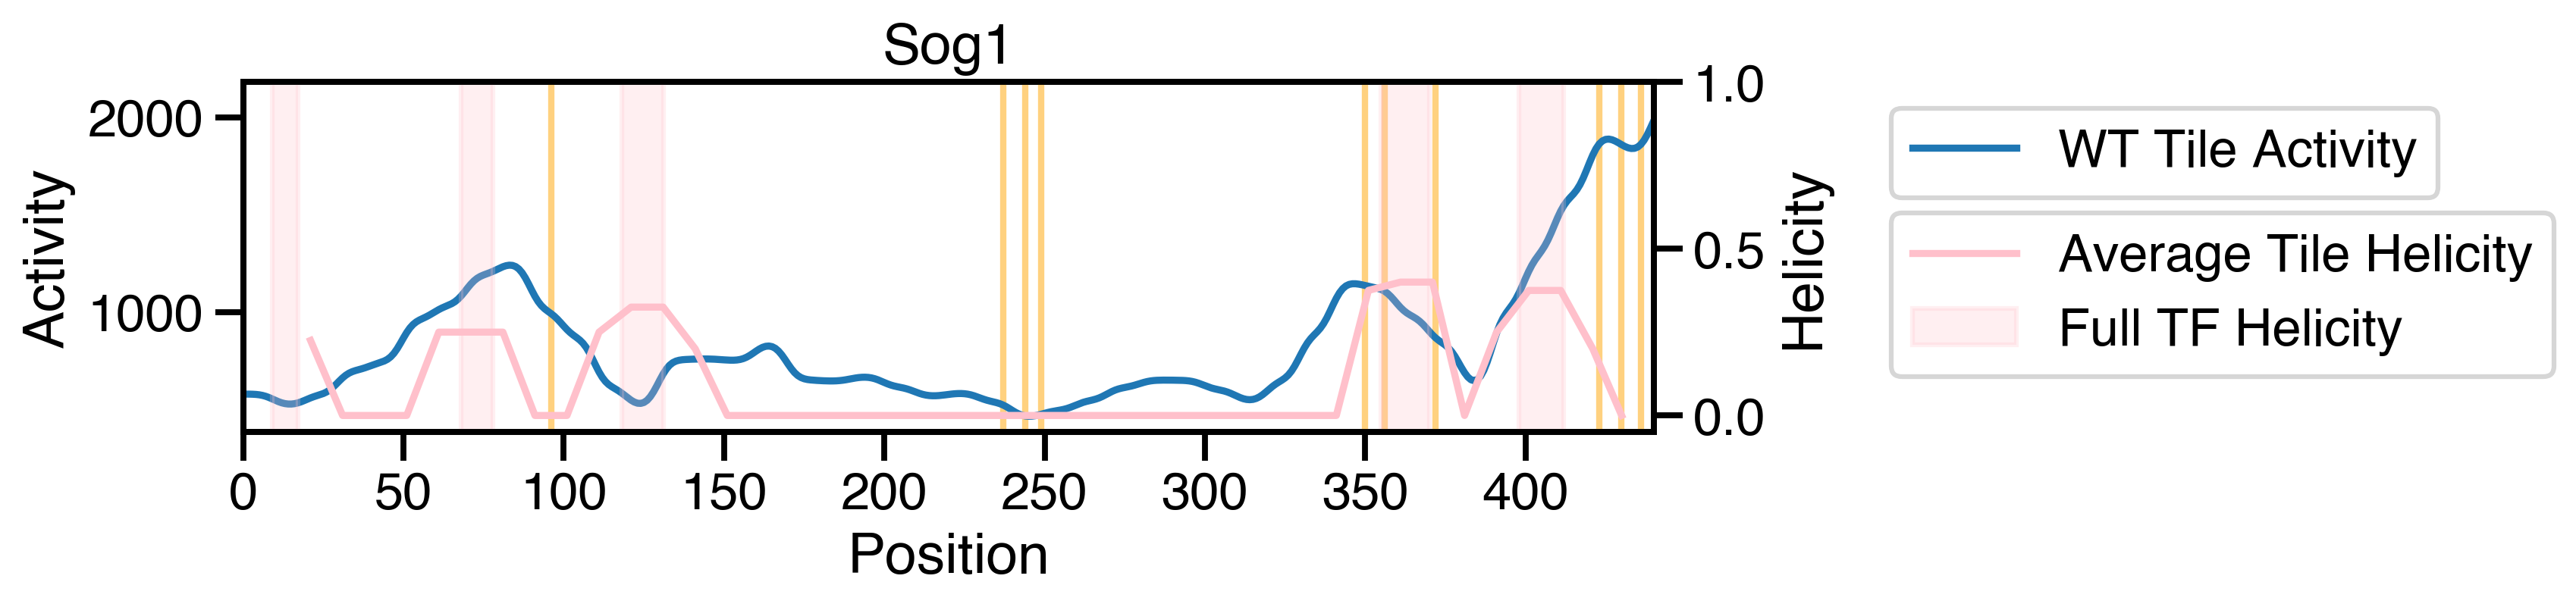

In [29]:
fig, ax = plt.subplots(figsize = (8, 2), dpi = 300)
sns.lineplot(wt_avg_activities["smoothed_avg_activity"], label = "WT Tile Activity", ax = ax, zorder = 10)
#sns.scatterplot(data = BasicArTh, x = "mid", y = "Activity_S3_1", ax = ax, s = 20, edgecolor = 'none')


    
ax.set_title("Sog1")
ax.set_ylabel("Activity")
ax.set_xlabel("Position")
ax.set_xlim(0, 440)

for pos in ps_locs["pos"]:
    ax.axvline(pos, color = "orange", zorder = 5, alpha = 0.5, lw = 2)

secax = ax.twinx()
sns.lineplot(data = BasicArTh, x = "mid", y = "helicity", color = 'pink', ax = secax, label = "Average Tile Helicity")
#sns.scatterplot(data = BasicArTh, x = "mid", y = "helicity", color = 'pink', ax = secax, s = 20, edgecolor = 'none')
secax.set_ylabel("Helicity")

label = True
for s, e in pred_helices:
    if label:
        secax.axvspan(s, e, alpha = 0.25, color = 'pink', label = "Full TF Helicity", zorder = 0)
        label = False
    else:
        secax.axvspan(s, e, alpha = 0.25, color = 'pink', zorder = 0)
secax.set_ylim(-0.05, 1)

ax.legend(bbox_to_anchor = (1.15,1))
secax.legend(bbox_to_anchor = (1.15,0.7))

#sns.despine()

In [30]:
wt_seq

'MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKAYSTGTRKRRKIHDDDFGDVRWHKTGRTKPVVLDGVQRGCKKIMVLYGGKAVKTNWVMHQYHLGIEEDEKEGDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATPEPRNAVRICSDSHIASDYVTPSDYVSAHEVSLAETSEVMCMEDEVQSIQPNHERPSSGPELEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLLGSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD'

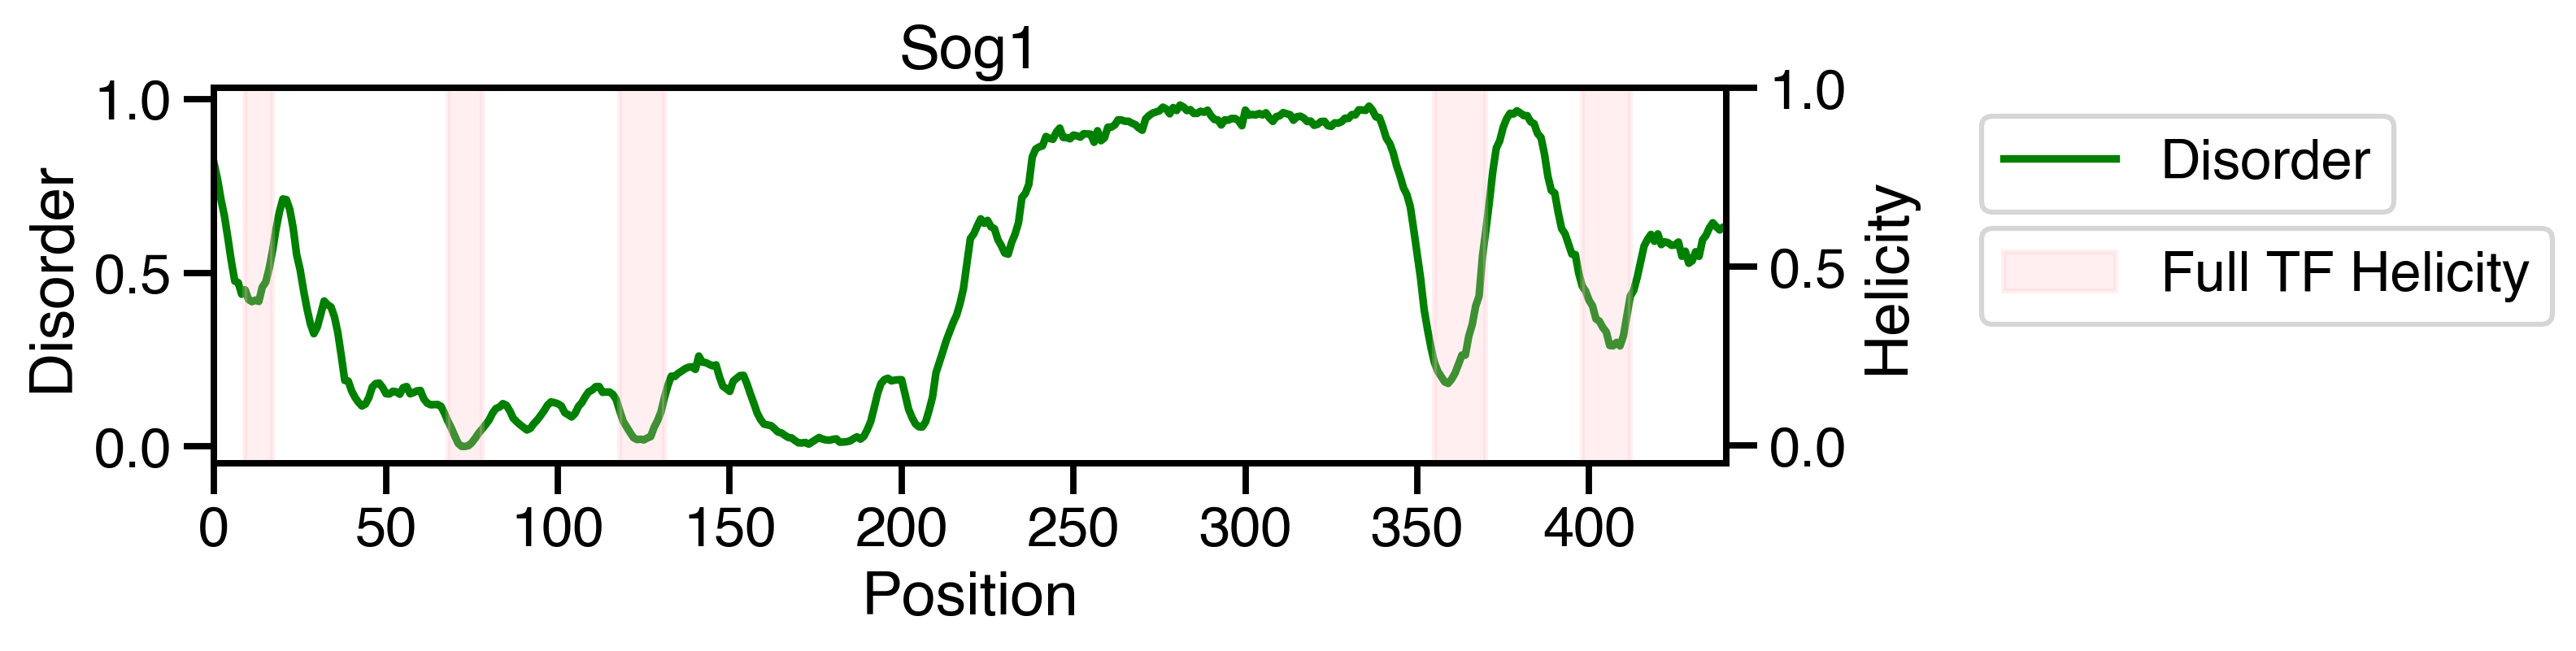

In [31]:
fig, ax = plt.subplots(figsize = (8, 2), dpi = 300)
sns.lineplot(meta.predict_disorder(wt_seq), ax = ax, color = "green", label = "Disorder")#sns.scatterplot(data = BasicArTh, x = "mid", y = "Activity_S3_1", ax = ax, s = 20, edgecolor = 'none')


    
ax.set_title("Sog1")
ax.set_ylabel("Disorder")
ax.set_xlabel("Position")
ax.set_xlim(0, 440)

# for pos in ps_locs["pos"]:
#     ax.axvline(pos, color = "orange", zorder = 5, alpha = 0.5, lw = 2)

secax = ax.twinx()
#sns.lineplot(data = BasicArTh, x = "mid", y = "helicity", color = 'pink', ax = secax, label = "Average Tile Helicity")
#sns.scatterplot(data = BasicArTh, x = "mid", y = "helicity", color = 'pink', ax = secax, s = 20, edgecolor = 'none')
secax.set_ylabel("Helicity")

label = True
for s, e in pred_helices:
    if label:
        secax.axvspan(s, e, alpha = 0.25, color = 'pink', label = "Full TF Helicity", zorder = 0)
        label = False
    else:
        secax.axvspan(s, e, alpha = 0.25, color = 'pink', zorder = 0)
secax.set_ylim(-0.05, 1)

ax.legend(bbox_to_anchor = (1.15,1))
secax.legend(bbox_to_anchor = (1.15,0.7))

#sns.despine()

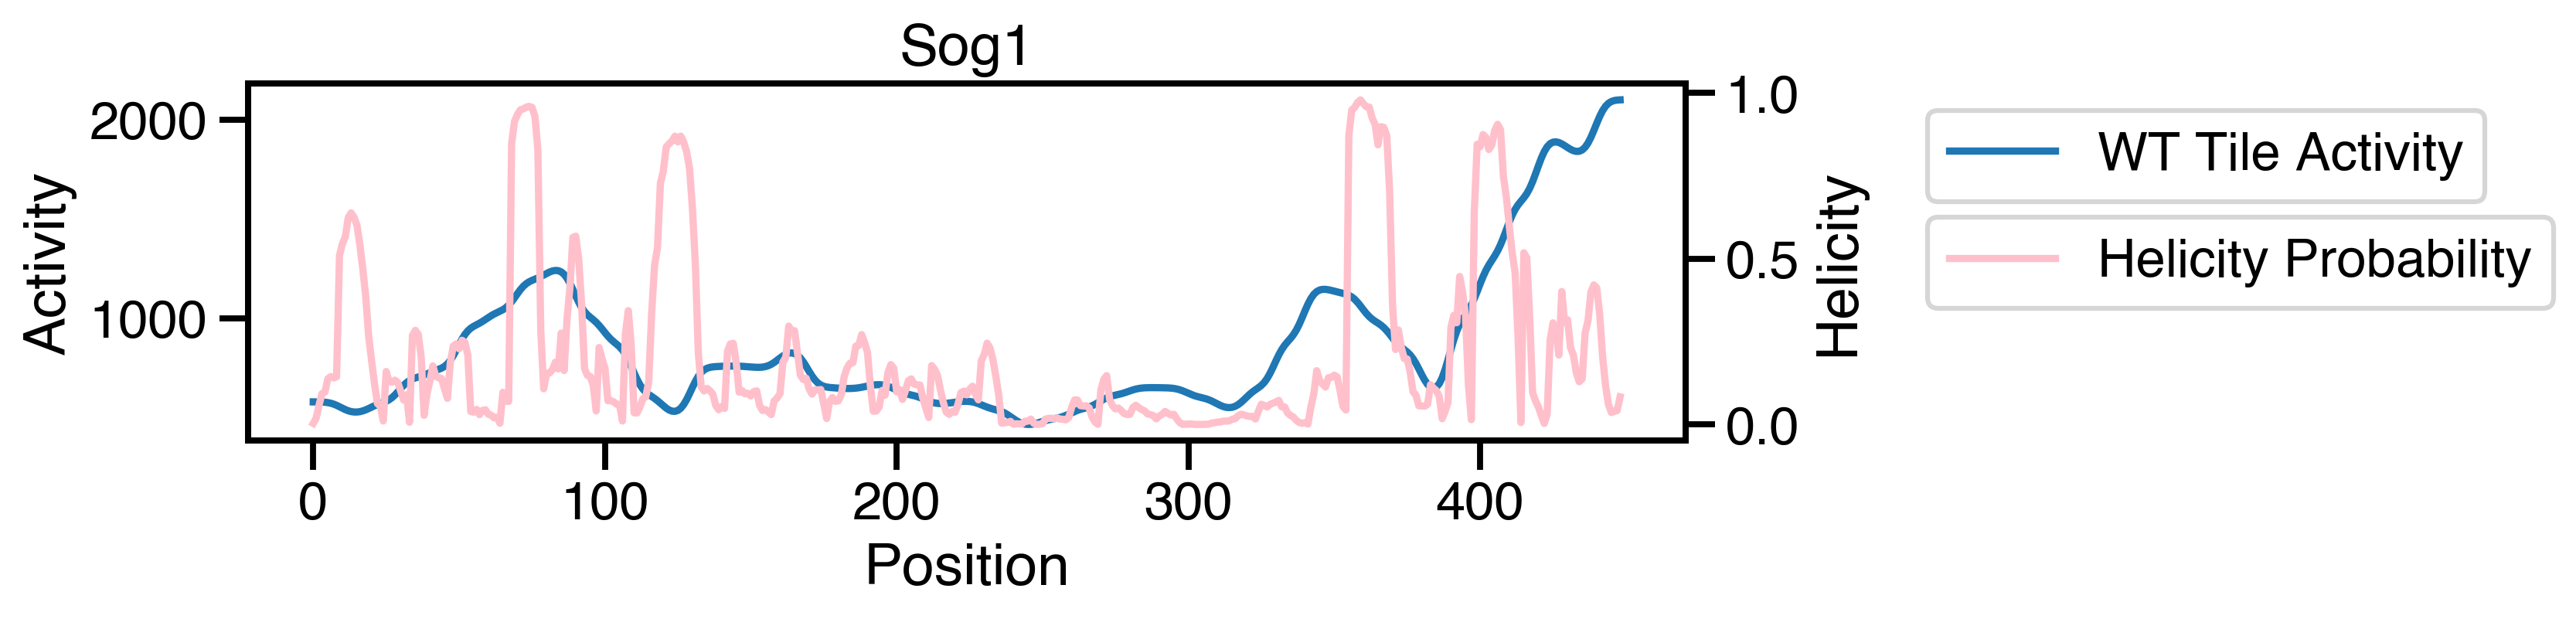

In [32]:
fig, ax = plt.subplots(figsize = (8, 2), dpi = 300)
sns.lineplot(wt_avg_activities["smoothed_avg_activity"], label = "WT Tile Activity", ax = ax, zorder = 10)
#sns.scatterplot(data = BasicArTh, x = "mid", y = "Activity_S3_1", ax = ax, s = 20, edgecolor = 'none')


    
ax.set_title("Sog1")
ax.set_ylabel("Activity")
ax.set_xlabel("Position")
#ax.set_xlim(0, 440)

# for pos in ps_locs["pos"]:
#     ax.axvline(pos, color = "orange", zorder = 5, alpha = 0.5, lw = 2)

secax = ax.twinx()
sns.lineplot(Protein(wt_seq).predictor.dssp_helicity(mode = 'probability'), ax = secax, color = 'pink', label = "Helicity Probability", zorder = 0)
#sns.scatterplot(data = BasicArTh, x = "mid", y = "helicity", color = 'pink', ax = secax, s = 20, edgecolor = 'none')
secax.set_ylabel("Helicity")

# label = True
# for s, e in pred_helices:
#     if label:
#         secax.axvspan(s, e, alpha = 0.25, color = 'pink', label = "Full TF Helicity", zorder = 0)
#         label = False
#     else:
#         secax.axvspan(s, e, alpha = 0.25, color = 'pink', zorder = 0)
# secax.set_ylim(-0.05, 1)

ax.legend(bbox_to_anchor = (1.15,1))
secax.legend(bbox_to_anchor = (1.15,0.7))

#sns.despine()

In [33]:
BasicArTh["avg_helicity_prob"] = BasicArTh["tile"].apply(lambda tile: avg_helicity_probability(tile))
BasicArTh

NameError: name 'avg_helicity_probability' is not defined

In [ ]:
sns.color_palette('colorblind')[-4]

(0.984313725490196, 0.6862745098039216, 0.8941176470588236)

In [ ]:
BasicArTh

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg,helicity,avg_helicity_prob
0,BasicArTh.1,Q6NQK2,1,21,41,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,349.798825,573.084946,461.441886,0.225,0.245707
1,BasicArTh.2,Q6NQK2,11,31,51,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,470.700956,2417.845241,1444.273098,0.000,0.142261
2,BasicArTh.3,Q6NQK2,21,41,61,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,867.654700,1328.781736,1098.218218,0.000,0.102768
3,BasicArTh.4,Q6NQK2,31,51,71,WKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPE,594.934332,3230.456725,1912.695529,0.000,0.076176
4,BasicArTh.5,Q6NQK2,41,61,81,KCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSG,667.974526,740.289998,704.132262,0.250,0.313890
5,BasicArTh.6,Q6NQK2,51,71,91,VVDDWPGLPRGVKFDPSDPEIIWHLLAKSGLSGLSSHPFI,1548.153317,1377.236177,1462.694747,0.250,0.325083
6,BasicArTh.7,Q6NQK2,61,81,101,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQD,1195.592810,1693.562924,1444.577867,0.250,0.393410
7,BasicArTh.8,Q6NQK2,71,91,111,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,553.464718,495.706275,524.585497,0.000,0.187146
8,BasicArTh.9,Q6NQK2,81,101,121,LSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTV,733.541576,756.101744,744.821660,0.000,0.068487
9,BasicArTh.10,Q6NQK2,91,111,131,DEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,495.092751,785.676325,640.384538,0.250,0.262324


In [34]:
sns.color_palette('colorblind')

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [53]:
BasicArTh

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,helicity,avg_helicity_probability
0,1,40,BasicArTh.1,Q6NQK2,21,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,4745,578.263724,889.304271,12,-311.040547,1467.567995,0.225,0.245707
1,11,50,BasicArTh.2,Q6NQK2,31,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4968,465.385382,365.182128,7,100.203254,830.567509,0.000,0.142261
2,21,60,BasicArTh.3,Q6NQK2,41,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,6208,680.357455,370.567756,11,309.789699,1050.925211,0.000,0.102768
3,31,70,BasicArTh.4,Q6NQK2,51,WKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPE,6737,1076.542492,1233.131826,8,-156.589334,2309.674317,0.000,0.076176
4,41,80,BasicArTh.5,Q6NQK2,61,KCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSG,3553,753.360897,406.043485,13,347.317413,1159.404382,0.250,0.313890
5,51,90,BasicArTh.6,Q6NQK2,71,VVDDWPGLPRGVKFDPSDPEIIWHLLAKSGLSGLSSHPFI,6654,1333.684743,539.101400,17,794.583343,1872.786144,0.250,0.325083
6,61,100,BasicArTh.7,Q6NQK2,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQD,3019,972.904562,473.415780,11,499.488782,1446.320342,0.250,0.393410
7,71,110,BasicArTh.8,Q6NQK2,91,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,3388,1704.401088,2314.845287,15,-610.444198,4019.246375,0.000,0.187146
8,81,120,BasicArTh.9,Q6NQK2,101,LSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTV,4676,992.490299,1209.571573,18,-217.081274,2202.061872,0.000,0.068487
9,91,130,BasicArTh.10,Q6NQK2,111,DEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,411,348.974668,137.172549,8,211.802119,486.147217,0.250,0.262324


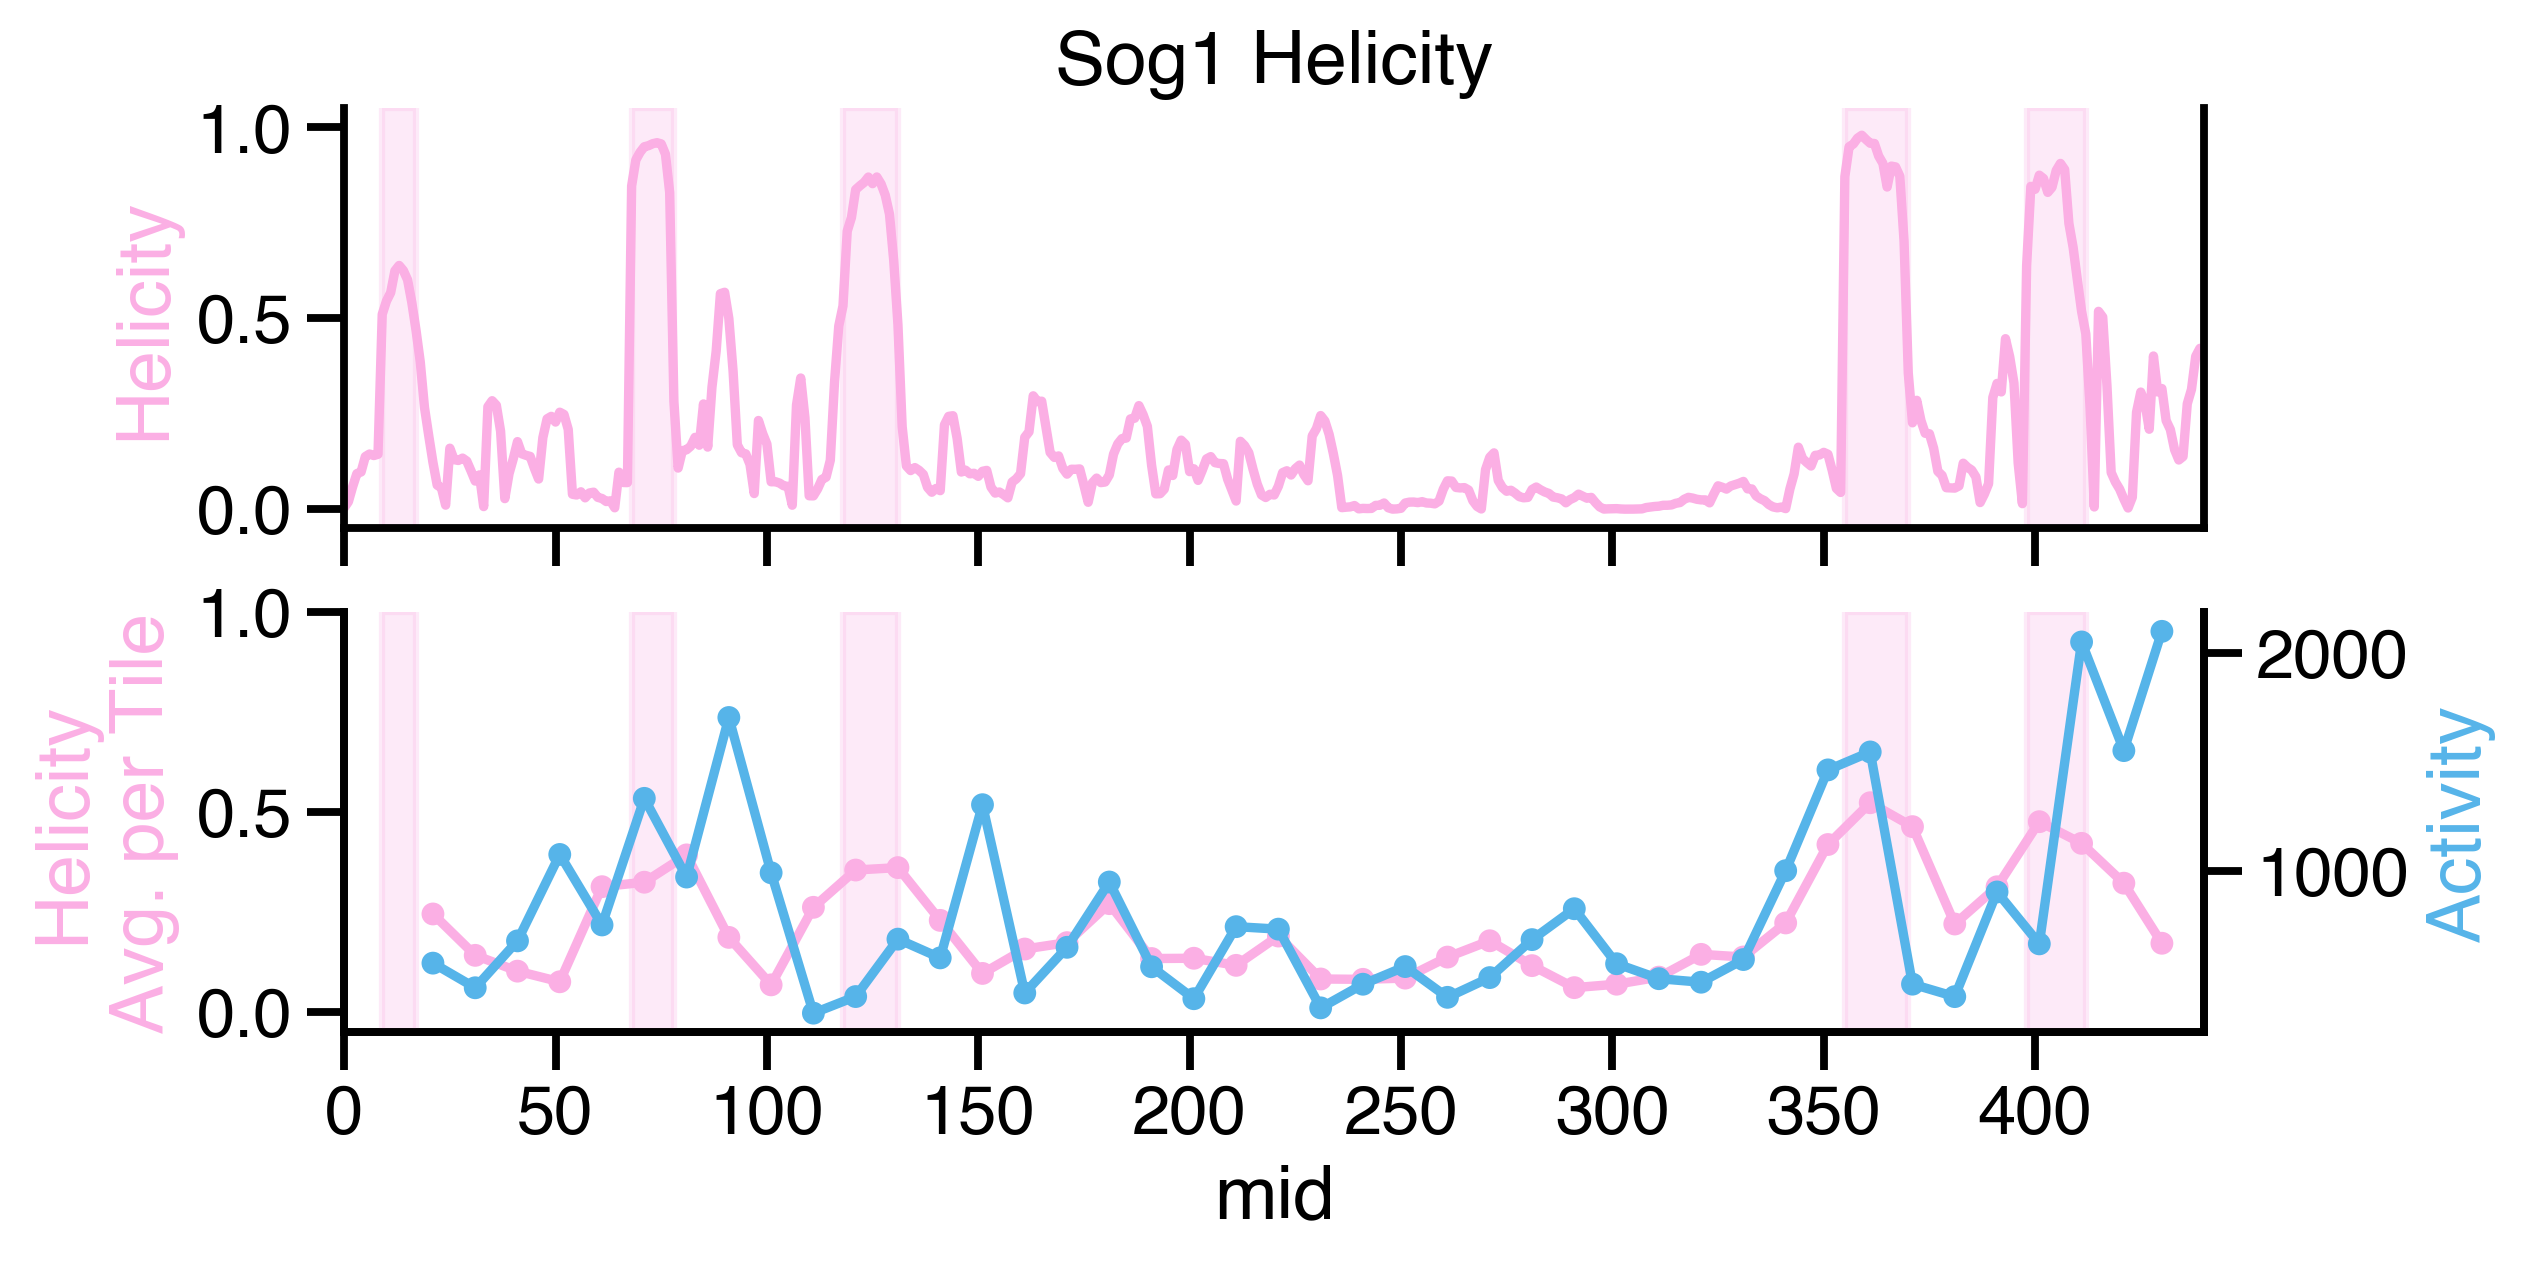

In [54]:
fig, axs = plt.subplots(2, 1, figsize = (8, 4), dpi = 300, sharex = True)

sns.lineplot(Protein(wt_seq).predictor.dssp_helicity(mode = 'probability'), 
             ax = axs[0], color = sns.color_palette('colorblind')[-4], zorder = 0)
axs[0].set_ylabel("Helicity", color = sns.color_palette('colorblind')[-4])

label = True
for s, e in pred_helices:
    if label:
        axs[0].axvspan(s, e, alpha = 0.25, color = sns.color_palette('colorblind')[-4], 
                       label = "Full TF Helicity", zorder = 0)
        label = False
    else:
        axs[0].axvspan(s, e, alpha = 0.25, color = sns.color_palette('colorblind')[-4],
                       zorder = 0)
axs[0].set_ylim(-0.05, 1.05)

secax = axs[1]
ax = secax.twinx()

sns.lineplot(x = BasicArTh["mid"], y = BasicArTh["Activity_S3_1"], 
             label = "WT Tile Activity\nAveraged+Smoothed", ax = ax, zorder = 10, 
             color = sns.color_palette('colorblind')[-1])
sns.scatterplot(x = BasicArTh["mid"], y = BasicArTh["Activity_S3_1"], 
             label = "WT Tile Activity\nAveraged+Smoothed", ax = ax, zorder = 10, 
             color = sns.color_palette('colorblind')[-1], s = 30, edgecolor = 'none')
ax.set_ylabel("Activity", color = sns.color_palette('colorblind')[-1])
ax.set_xlabel("Position")
ax.set_xlim(0, 440)



sns.lineplot(data = BasicArTh, x = "mid", y = "avg_helicity_probability", color = sns.color_palette('colorblind')[-4], 
             ax = secax, 
             label = "Average Tile\nHelicity Probability")
sns.scatterplot(data = BasicArTh, x = "mid", y = "avg_helicity_probability", color = sns.color_palette('colorblind')[-4], 
             ax = secax, 
             label = "Average Tile\nHelicity Probability", s = 30, edgecolor = 'none')
secax.set_ylabel("Helicity\nAvg. per Tile", color =  sns.color_palette('colorblind')[-4], weight = 'bold')

for s, e in pred_helices:
    if label:
        ax.axvspan(s, e, alpha = 0.25, color = sns.color_palette('colorblind')[-4], label = "Full TF Helicity", zorder = 0)
        label = False
    else:
        ax.axvspan(s, e, alpha = 0.25, color = sns.color_palette('colorblind')[-4], zorder = 0)

secax.set_ylim(-0.05, 1)

#ax.legend(bbox_to_anchor = (1.15,1))
#secax.legend(bbox_to_anchor = (1.15,0.55))
ax.get_legend().remove()
secax.get_legend().remove()

axs[0].set_title("Sog1 Helicity")

sns.despine(right = False)
plt.savefig("../output/figures/helicity/helicity_overview.png", bbox_inches='tight')

In [36]:
def avg_helicity_probability(seq):
    P = Protein(seq) 
    output = P.predictor.dssp_helicity(mode = 'probability')
    return sum(output) / len(output)

In [37]:
avg_helicity_probability(wt_seq)

0.21121710835360624

In [38]:
percent_helicity(wt_seq)

0.133630289532294

In [51]:
BasicArTh["avg_helicity_probability"] = BasicArTh["tile"].apply(lambda tile: avg_helicity_probability(tile))

In [39]:
all_shuffle_vars["avg_helicity_probability"] = all_shuffle_vars["tile_var"].apply(lambda tile: avg_helicity_probability(tile))
all_shuffle_vars

,Unnamed: 0,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,...,vars,AAs,tile,shuffle_size,coordinates,pos_start,pos_end,helicity,end_to_end,avg_helicity_probability
0,0,321,360,33_shuffle_size2_ss2_pos0_1,shuffle_size2_ss2_pos0_1,341,MELDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,763.760346,695.590132,729.675239,...,"[321, 322]","['E', 'M']",33,2,0_1,321,323,0.0,44.168199,0.215530
1,1,321,360,33_shuffle_size2_ss2_pos1_1,shuffle_size2_ss2_pos1_1,341,EMDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1473.675797,1687.523804,1580.599801,...,"[323, 324]","['L', 'D']",33,2,1_1,323,325,0.0,44.742841,0.229807
2,2,321,360,33_shuffle_size2_ss2_pos2_1,shuffle_size2_ss2_pos2_1,341,EMLDKDEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1706.977440,1719.464603,1713.221022,...,"[325, 326]","['D', 'K']",33,2,2_1,325,327,0.0,44.660848,0.218102
3,3,321,360,33_shuffle_size2_ss2_pos4_1,shuffle_size2_ss2_pos4_1,341,EMLDDKEEEQKDRDNENQGEEDPTWFDSGSQFILNSQQLV,325.349781,627.000002,476.174892,...,"[329, 330]","['Q', 'E']",33,2,4_1,329,331,0.0,44.339531,0.232722
4,4,321,360,33_shuffle_size2_ss2_pos5_1,shuffle_size2_ss2_pos5_1,341,EMLDDKEEQEDKRDNENQGEEDPTWFDSGSQFILNSQQLV,677.584266,878.104555,777.844411,...,"[331, 332]","['K', 'D']",33,2,5_1,331,333,0.0,43.952220,0.215462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568,3568,410,449,42_shuffle_size10_ss2_pos15_6,shuffle_size10_ss2_pos15_6,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSLWTGADFGTK,908.291934,601.458747,754.875341,...,"[440, 441, 442, 443, 444, 445, 446, 447, 449]","['F', 'L', 'A', 'W', 'G', 'T', 'G', 'K', 'D']",42,10,15_6,440,450,0.0,44.446552,0.156352
3569,3569,410,449,42_shuffle_size10_ss2_pos15_7,shuffle_size10_ss2_pos15_7,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTTKGDALWFG,3620.400685,3866.897601,3743.649143,...,"[440, 441, 442, 443, 444, 445, 446, 447, 448, ...","['F', 'L', 'A', 'W', 'G', 'T', 'G', 'K', 'T', ...",42,10,15_7,440,450,0.0,42.868909,0.119842
3570,3570,410,449,42_shuffle_size10_ss2_pos15_8,shuffle_size10_ss2_pos15_8,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTLDFGKGATW,1014.433117,629.787497,822.110307,...,"[440, 442, 443, 445, 447, 449]","['F', 'A', 'W', 'T', 'K', 'D']",42,10,15_8,440,450,0.0,45.132755,0.132447
3571,3571,410,449,42_shuffle_size10_ss2_pos15_9,shuffle_size10_ss2_pos15_9,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTWFTGGADLK,2375.766170,1866.065374,2120.915772,...,"[440, 441, 442, 443, 445, 446, 447, 448, 449]","['F', 'L', 'A', 'W', 'T', 'G', 'K', 'T', 'D']",42,10,15_9,440,450,0.0,44.190105,0.142060


In [407]:
def plot_one_tile_scatter(tile, ax, col = "avg_helicity_probability", func = True, end_to_end = False):
    one_tile = all_shuffle_vars[all_shuffle_vars["tile"] == tile]

    palette = sns.color_palette('colorblind')
    
    sns.set_context('talk')
    sns.scatterplot(data = one_tile, x = col, y = "Activity_S3_1_var", 
                    alpha = 0.25, edgecolor = 'none', ax = ax, color = palette[0], s = 10)
    if func:
        ax.axvline(avg_helicity_probability(one_tile["tile_wt"].iloc[0]), color = "red", zorder = 0, alpha = 0.25)
    if end_to_end:
        ax.axvline(end_to_end_dist(one_tile["tile_wt"].iloc[0]), color = "red", zorder = 0, alpha = 0.25)
    ax.axhline(one_tile["Activity_S3_1_wt"].iloc[0], color = "red", zorder = 0, alpha = 0.25)
    ax.set_title("Tile " + str(tile) + ": " + str(one_tile["Start"].iloc[0]) + "-" + str(one_tile["End"].iloc[0]))
    sns.despine()
    

NameError: name 'plot_one_tile_scatter' is not defined

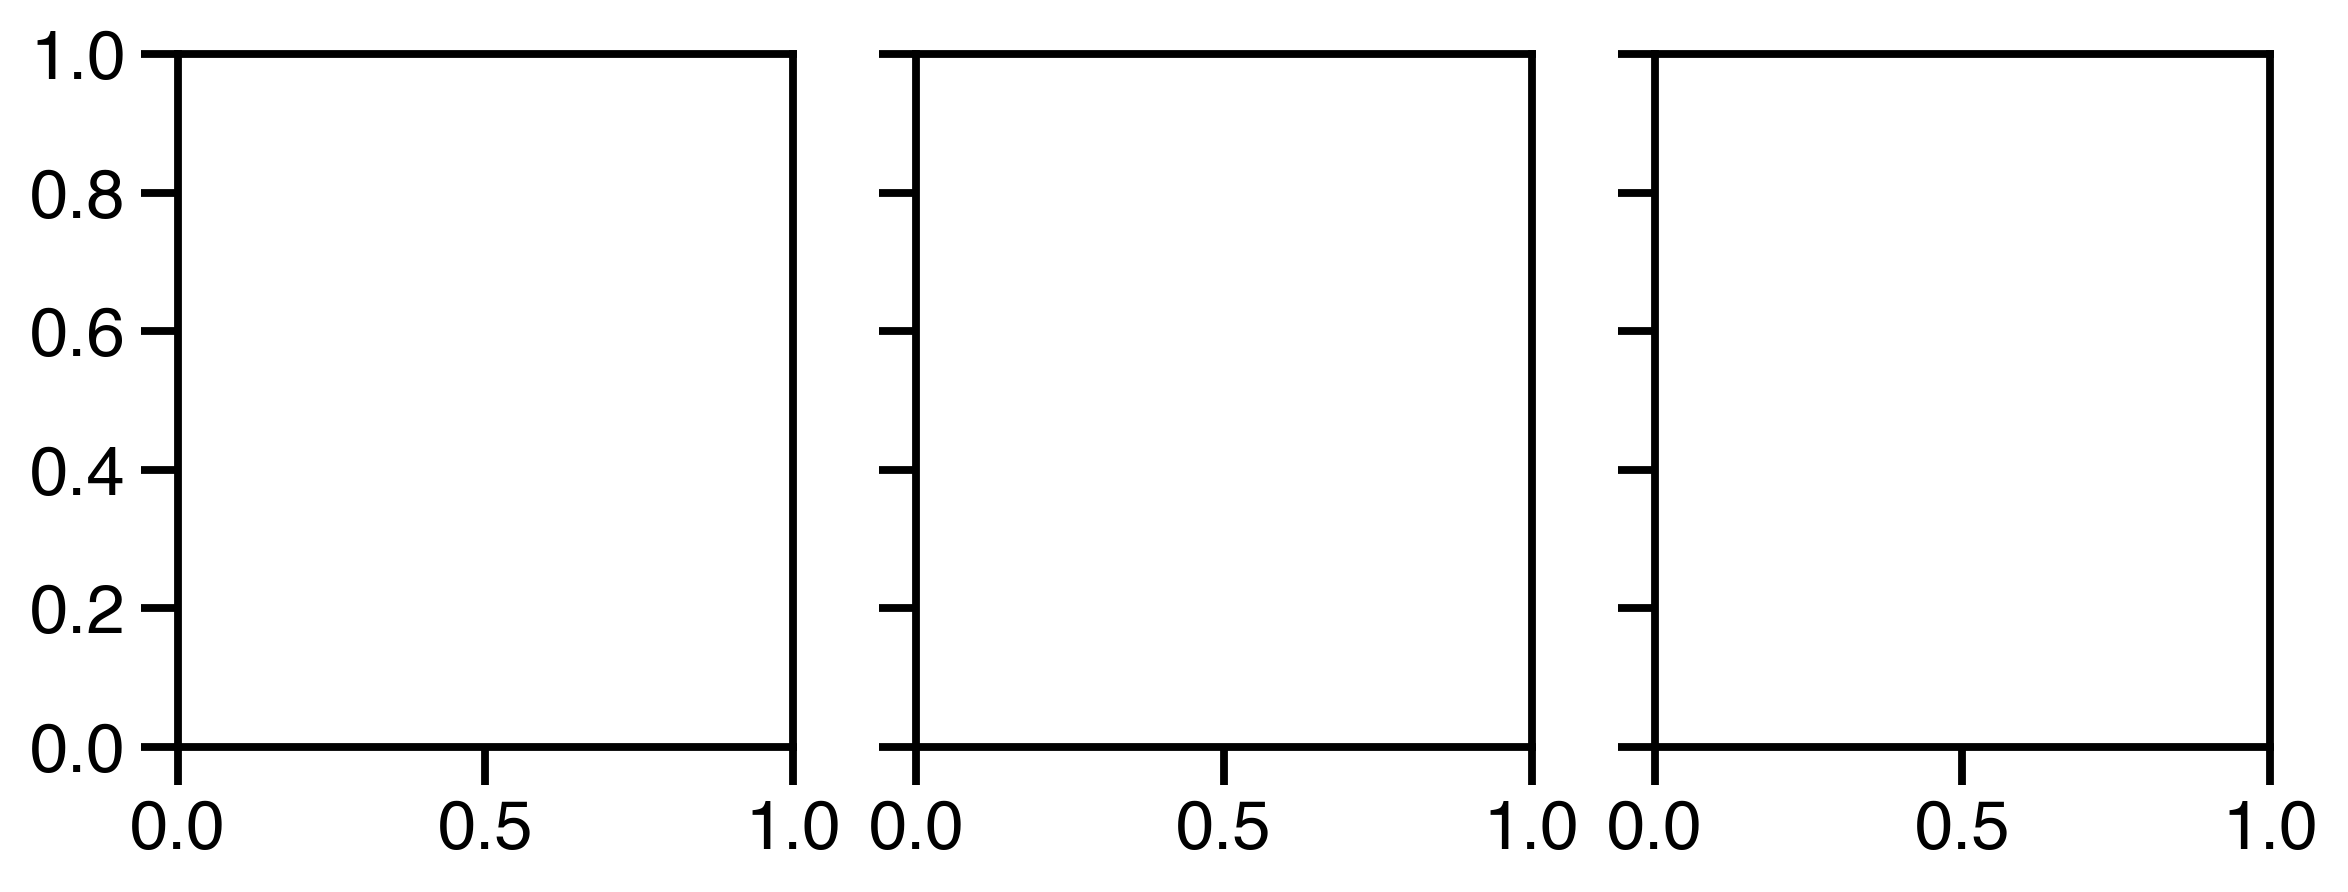

In [43]:
fig, axs = plt.subplots(1, 3, figsize = (9, 3), dpi = 300, sharey = True)
plot_one_tile_scatter(33, axs[0], col = "end_to_end", func = False, end_to_end = True)
plot_one_tile_scatter(34, axs[1], col = "end_to_end", func = False, end_to_end = True)
plot_one_tile_scatter(35, axs[2], col = "end_to_end", func = False, end_to_end = True)
for ax in axs:
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.supylabel("Activity", x= -0.005)
fig.supxlabel("Tile End to End Distance", y = -0.15)
plt.savefig("../output/figures/helicity/tile_33-35_end_to_end.png", bbox_inches='tight')

NameError: name 'plot_one_tile_scatter' is not defined

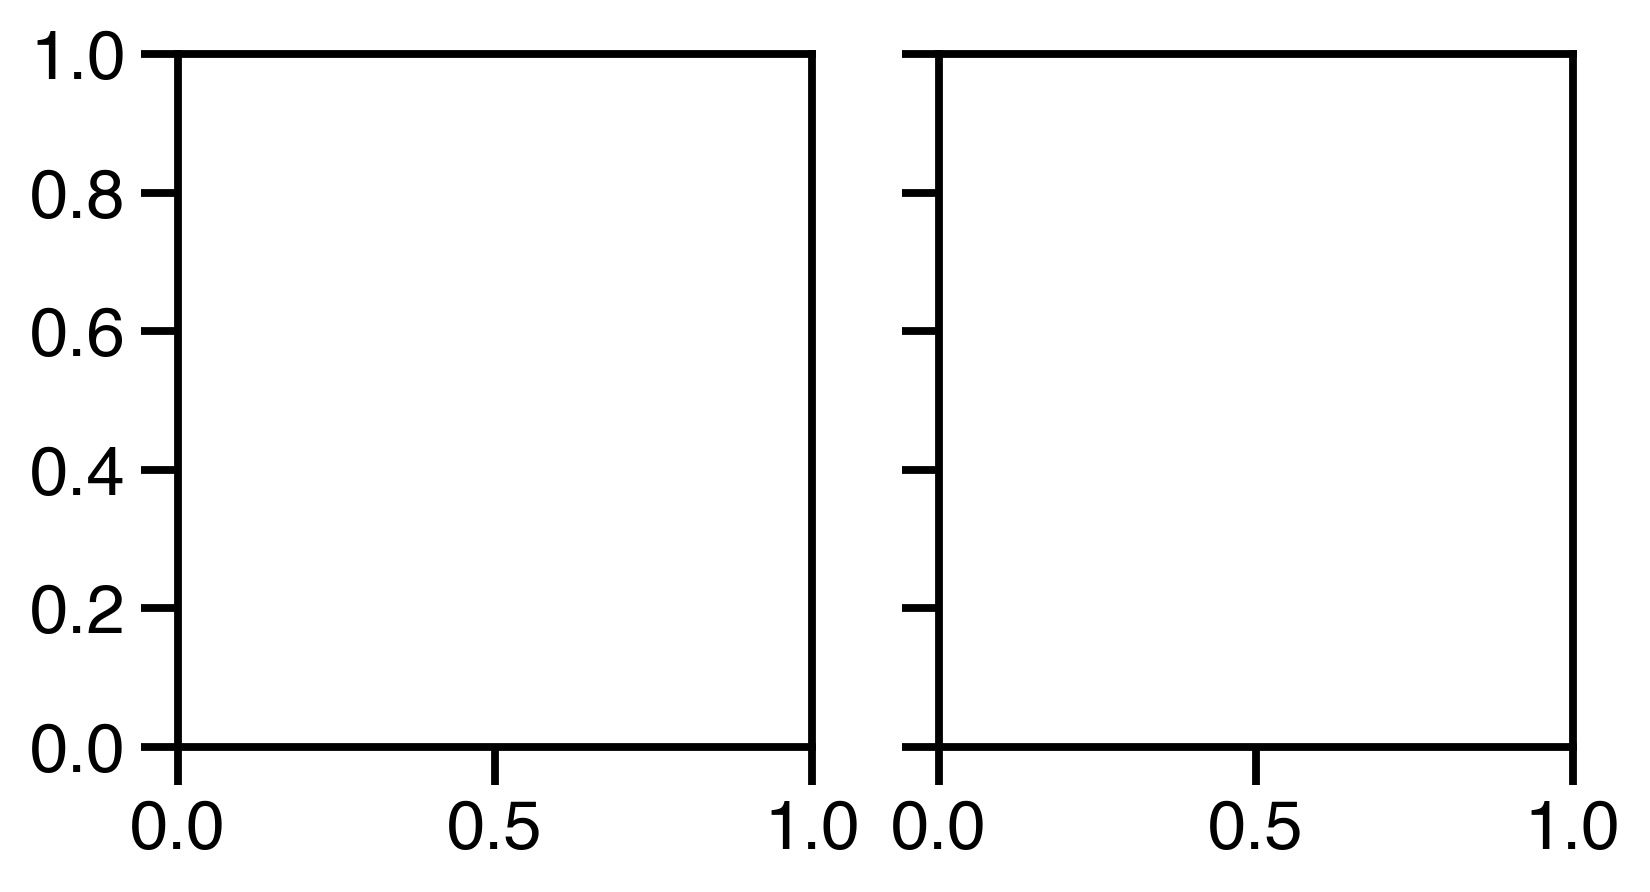

In [44]:
fig, axs = plt.subplots(1, 2, figsize = (6, 3), dpi = 300, sharey = True)
plot_one_tile_scatter(41, axs[0], col = "end_to_end", func = False, end_to_end = True)
plot_one_tile_scatter(42, axs[1], col = "end_to_end", func = False, end_to_end = True)
for ax in axs:
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.supylabel("Activity", x= -0.05)
fig.supxlabel("Tile End to End Distance", y = -0.15)
plt.savefig("../output/figures/helicity/tile_41-42_end_to_end.png", bbox_inches='tight')

NameError: name 'plot_one_tile_scatter' is not defined

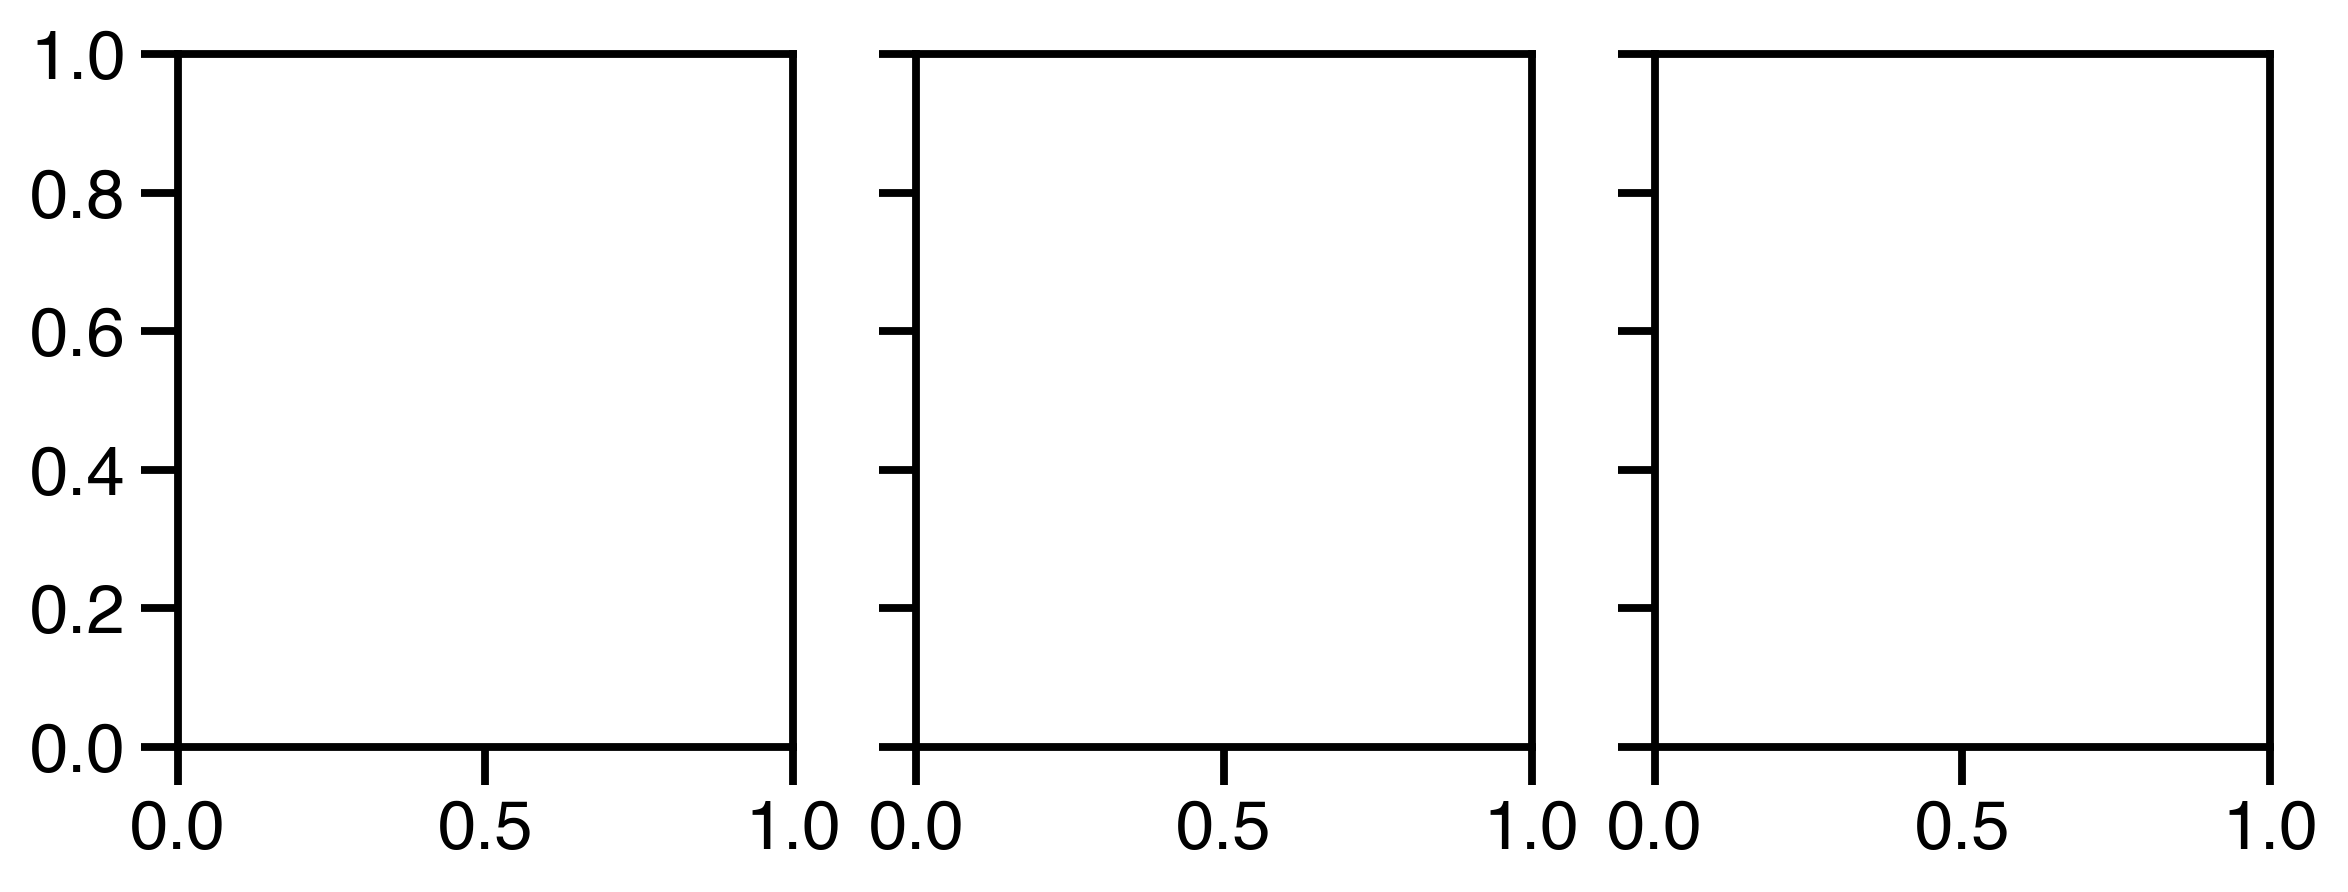

In [45]:
fig, axs = plt.subplots(1, 3, figsize = (9, 3), dpi = 300, sharey = True)
plot_one_tile_scatter(33, axs[0])
plot_one_tile_scatter(34, axs[1])
plot_one_tile_scatter(35, axs[2])
for ax in axs:
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.supylabel("Activity", x= -0.005)
fig.supxlabel("Average Tile Helicity Probability", y = -0.15)
plt.savefig("../output/figures/helicity/tile_33-35_avg_helicity_prob.png", bbox_inches='tight')

NameError: name 'plot_one_tile_scatter' is not defined

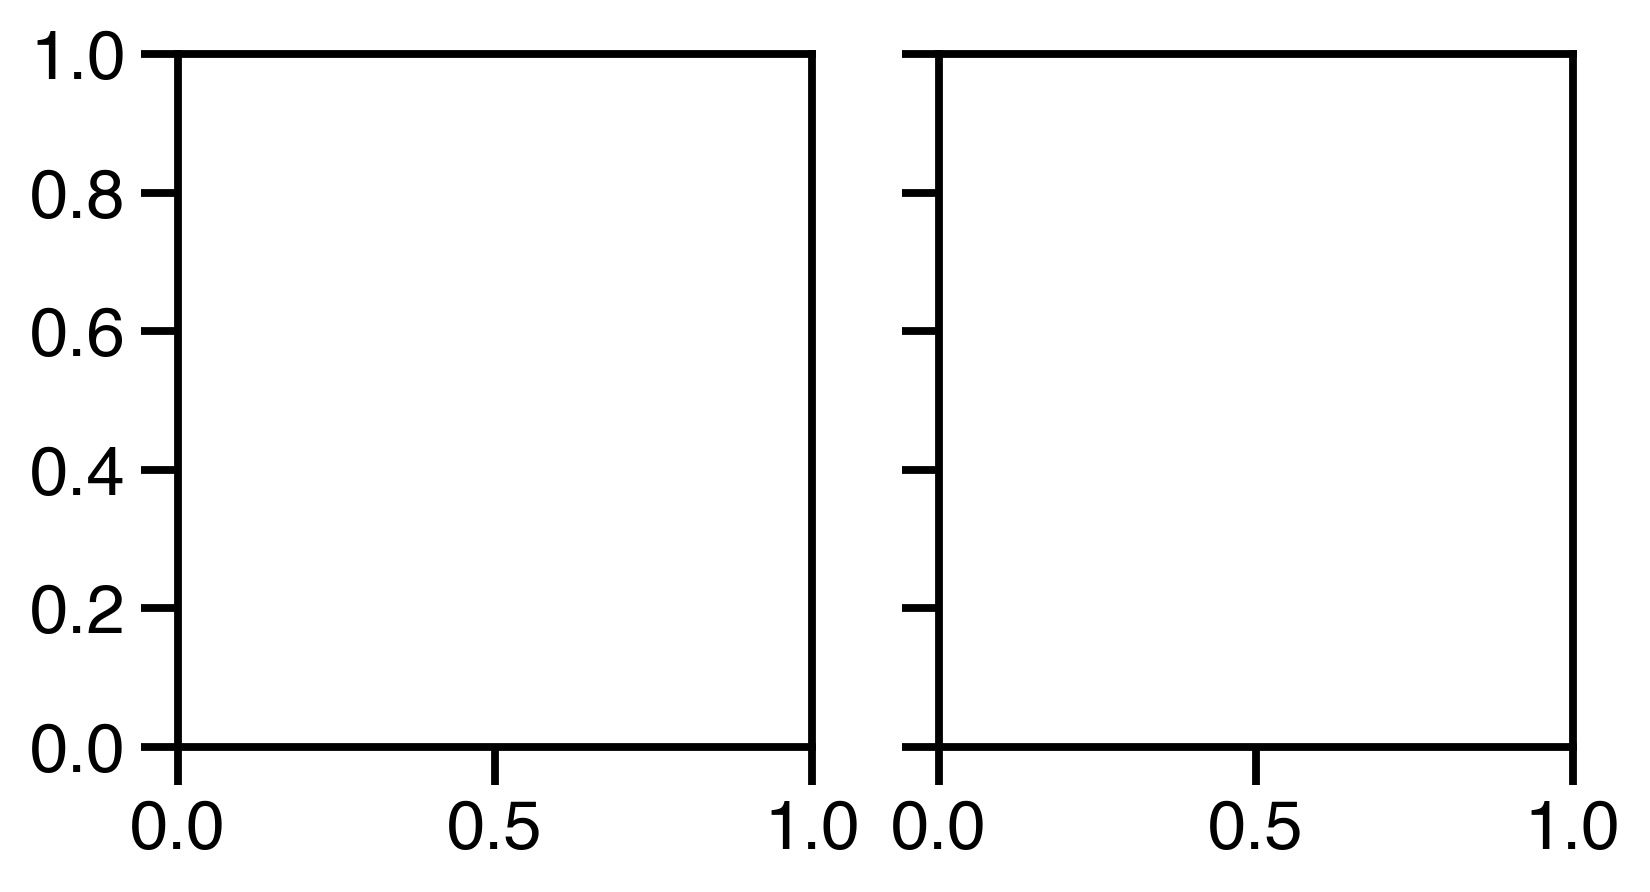

In [46]:
fig, axs = plt.subplots(1, 2, figsize = (6, 3), dpi = 300, sharey = True)
plot_one_tile_scatter(41, axs[0])
plot_one_tile_scatter(42, axs[1])
for ax in axs:
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.supylabel("Activity", x= -0.05)
fig.supxlabel("Average Tile Helicity Probability", y = -0.15)
plt.savefig("../output/figures/helicity/tile_41-42_avg_helicity_prob.png", bbox_inches='tight')

In [47]:
def within_helix_1_avg_prob(tile, ax):
    tile_34 = all_shuffle_vars[all_shuffle_vars["tile"] == tile]
    tile_34_helix = tile_34[tile_34["pos_start"] >= 356]
    tile_34_helix = tile_34_helix[tile_34_helix["pos_end"] <= 371]
    
    sns.scatterplot(data = tile_34_helix, x = "avg_helicity_probability", y = "Activity_S3_1_var", alpha = 0.5, edgecolor = 'none', color = palette[0], s = 15, ax = ax) 
    sns.despine()
    #ax.set_title("Tile " + str(tile))
    ax.set_title("Tile " + str(tile) + ": " + str(tile_34_helix["Start"].iloc[0]) + "-" + str(tile_34_helix["End"].iloc[0]))
    
    ax.axvline(percent_helicity(tile_34["tile_wt"].iloc[0]), color = "red", zorder = 0, alpha = 0.25)
    ax.axhline(tile_34["Activity_S3_1_wt"].iloc[0], color = "red", zorder = 0, alpha = 0.25)
    

Text(0.5, 1.1, 'Shuffles in Helix 356-371')

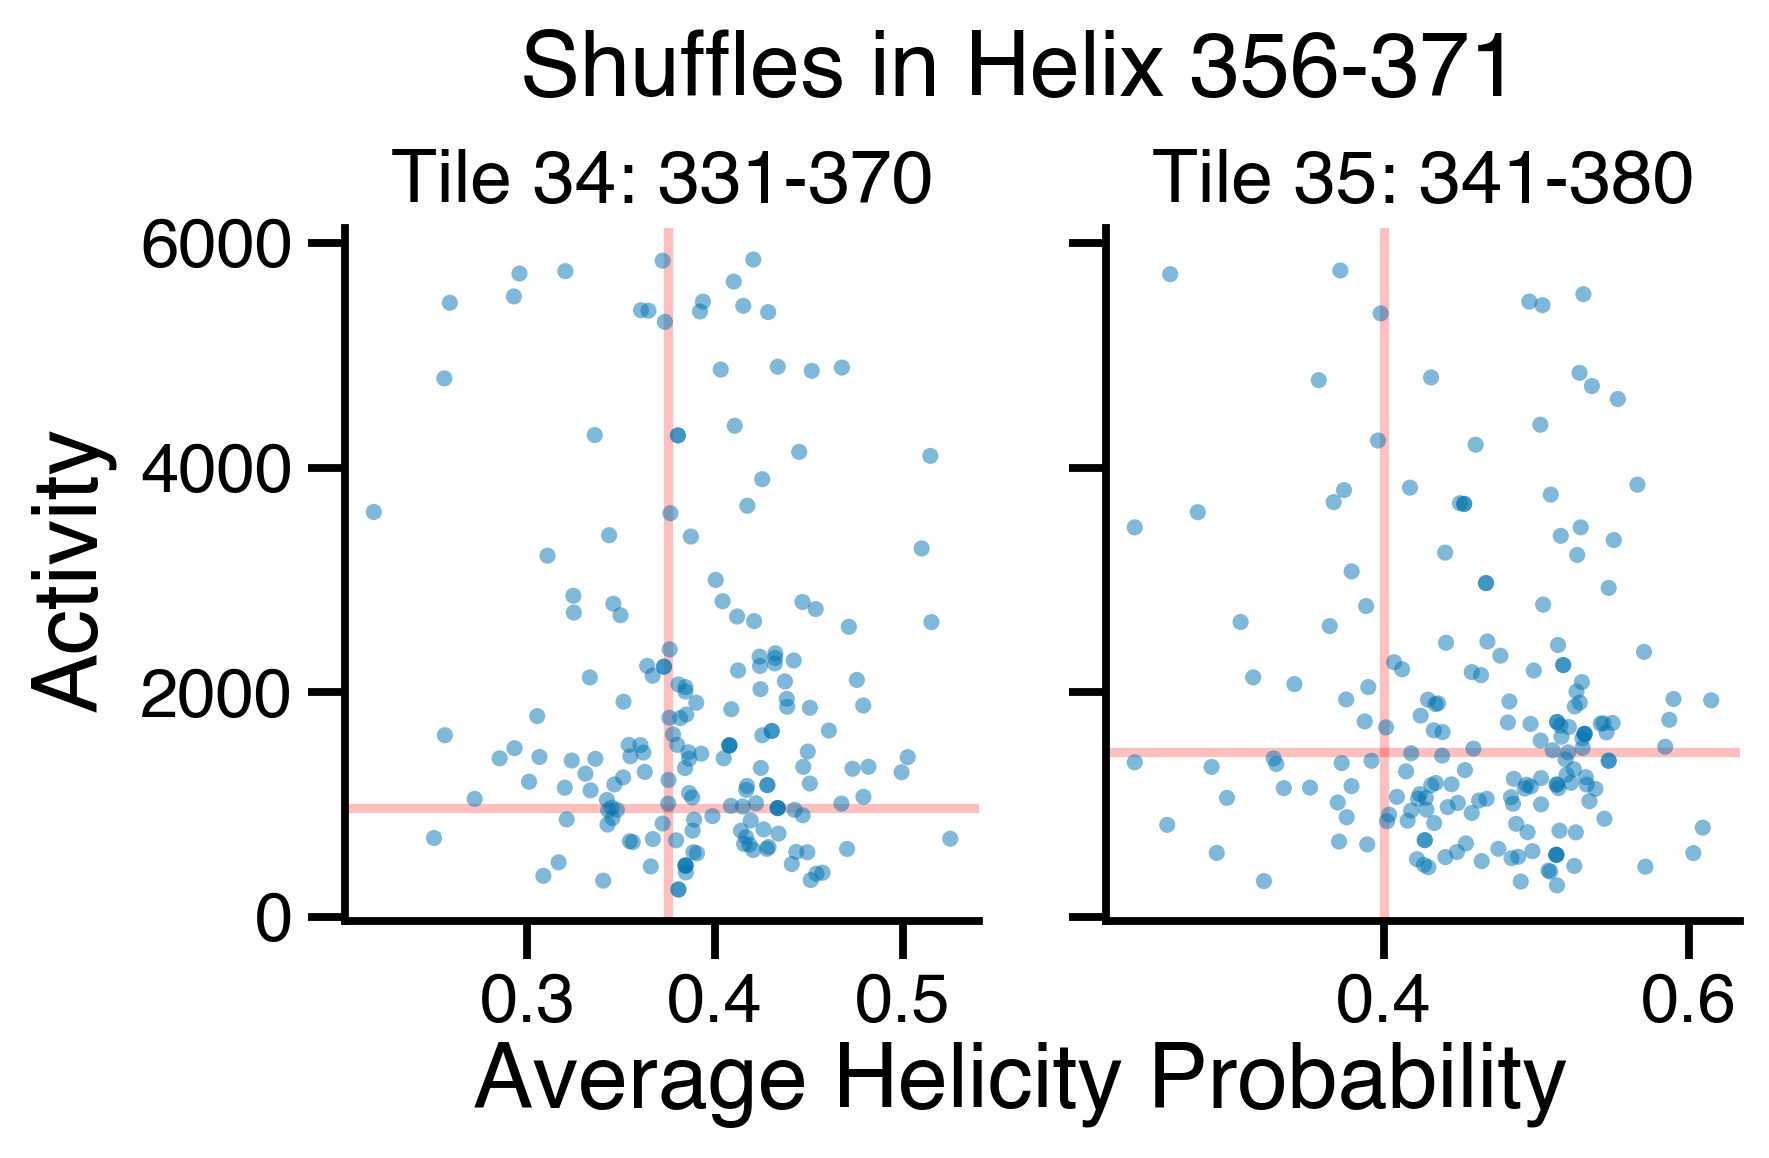

In [48]:
fig, axs = plt.subplots(1, 2, figsize = (6,3), dpi = 300, sharey = True)
within_helix_1_avg_prob(34, axs[0])
within_helix_1_avg_prob(35, axs[1])
for ax in axs:
    ax.set_ylabel("")
    ax.set_xlabel("")
fig.supylabel("Activity", x= -0.05)
fig.supxlabel("Average Helicity Probability", y = -0.12)
fig.suptitle("Shuffles in Helix 356-371",y = 1.1)

In [49]:
within_helix_1_avg_prob(34)

TypeError: within_helix_1_avg_prob() missing 1 required positional argument: 'ax'